[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nishani53/Khanal_MSc_Thesis_MSU/blob/main/Network%20Analysis%20Michigan%20Forestry/Khanal%20Network%20Analysis%20MSU.ipynb)




# 🌲 Forest Market Coverage & Forest Area Overlay Analysis

This repository contains scripts and data for quantifying **forest area** within **procurement zones** of biomass, hardwood, softwood, and pulpwood markets in Michigan, across multiple decades.  
It also identifies how much forest land was **retained**, **lost**, or **newly added** to market coverage between years, broken down by **forest type**.

---

## 📌 Objective

To accurately measure forestland within market coverage zones for:

- 🌳 **Hardwood Sawlogs**
- 🌲 **Softwood Sawlogs**
- 🧻 **Pulpwood**
- 🔥 **Biomass**

The workflow overlays **market coverage shapefiles** with **forest cover and forest type rasters** to calculate area (in acres) by forest group and track temporal changes.

---

## 🗺️ Data Sources

### 1. **Market Coverage Shapefiles**
- Represent procurement zones for different products and years.
- Contain a `status` field with:
  - **Market Retain** – areas present in both time periods
  - **Market Loss** – areas present in earlier period only
  - **Market Add** – areas new in the later period

### 2. **Competition Class Hotspot Maps**
- Dissolved polygons showing overlapping procurement zones.
- Classified into:
  - `1 - Lowest`
  - `2 - Low`
  - `3 - Medium`
  - `4 - High`

### 3. **Forest Cover & Forest Type Rasters**
- **NLCD Land Cover** (2001, 2019) – identifies forest/non-forest pixels.
- **FIA Forest Type Groups** – classifies forest by species group.
- ~30m resolution.

---

## 🧠 Method Overview

1. **Reprojection** – All shapefiles reprojected to raster CRS.
2. **Raster Clipping** – Each polygon masks the raster to extract only relevant pixels.
3. **Filtering** – Select only valid forest classes or forest type groups.
4. **Area Calculation** – Count pixels × pixel area (m²) → acres.
5. **Summarization** – Report total forest area and breakdown by forest type.

---

## 🛠️ Python Libraries Used

- [`geopandas`](https://geopandas.org/) – vector data handling
- [`matplotlib`](https://matplotlib.org/) – mapping and visualization
- [`rasterio`](https://rasterio.readthedocs.io/) – raster I/O and masking
- [`fiona`](https://fiona.readthedocs.io/) – shapefile I/O
- [`shapely`](https://shapely.readthedocs.io/) – geometry operations
- [`pyproj`](https://pyproj4.github.io/pyproj/stable/) – coordinate transformations
- [`numpy`](https://numpy.org/) – pixel counting and calculations

---

## 📈 Output Examples

For each polygon:
- **Total forest area** (acres)
- **Forest area by type group** (acres)
- Side-by-side plots of **undissolved** (competition classes) vs. **dissolved** (full coverage)

Example change classification visualization:

| Status         | Color      |
|----------------|------------|
| Market Retain  | Light Gray |
| Market Loss    | Red        |
| Market Add     | Blue       |

---

## 📂 Repository Structure

```
Data/
    biomass_coverage_*.shp
    biomass_change_*-*.shp
    hardwood_coverage_*.shp
    hardwood_change_*-*.shp
    softwood_coverage_*.shp
    softwood_change_*-*.shp
    pulpwood_coverage_*.shp
    pulpwood_change_*-*.shp
    *_hotspots_*.shp
    Counties_(v17a).shp
    forest_cover_2019.tif
    lulc2001.tif
Scripts/
    01_generate_change_shapefiles.py
    02_visualize_changes.py
    03_forest_cover_area_calculation.py
    04_forest_type_area_calculation.py
Outputs/
    Plots/
    Tables/
README.md
```

---

## 🚀 Usage

**Run in Colab:**  
Click the badge at the top to open the main notebook in Google Colab with all dependencies pre-installed.

**Local Execution:**  
1. Clone the repository:
```bash
git clone https://github.com/Nishani53/Khanal_MSc_Thesis_MSU.git
```
2. Install dependencies:
```bash
pip install geopandas matplotlib rasterio fiona shapely pyproj numpy
```
3. Run analysis scripts from the `Scripts` folder.

---

## 📅 Time Periods Analyzed
- **1985–1994**
- **1994–2002**
- **2002–2018**
- **2018–2023**
- **1985–2023** (long-term change)

---

## 📜 License
This repository is for academic research. Please contact the author before reuse or redistribution.


In [6]:
! pip install geopandas rasterio numpy matplotlib
! pip install --upgrade rasterio
!pip install rasterio geopandas shapely
!pip install geopandas fiona
!pip install matplotlib-scalebar
!pip install gdown
!pip install pydrive
!pip install matplotlib-scalebar

In [7]:
# 📁 Step 1: Clean Colab working directory
%cd /content
!rm -rf sample_data/ repo.zip Khanal_MSc_Thesis_MSU-main "Khanal Thesis Data.7z"

# 🛠️ Step 2: Install 7-Zip
!apt-get install -y p7zip-full

# 📥 Step 3: Download your GitHub repo zip
!curl -L -o repo.zip https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/archive/refs/heads/main.zip
!unzip -q repo.zip

# 📂 Step 4: Navigate to the folder containing 'Khanal Thesis Data.7z'
%cd "Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data"

# 📥 Step 5: Download 'Khanal Thesis Data.7z' from GitHub (fresh copy)
!curl -L -o "Khanal Thesis Data.7z" "https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/raw/main/Network%20Analysis%20Michigan%20Forestry/Data/Khanal%20Thesis%20Data.7z"

# 📂 Step 6: Extract the .7z archive
!7z x -y "Khanal Thesis Data.7z"

# 📂 Step 7: Set base path to extracted Data folder inside the archive
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

import os

# 📃 Step 8: List all files recursively
print("📁 Listing all files in extracted Data folder:\n")
for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))

# 📑 Step 9: List only shapefiles and raster files
shp_ext = ".shp"
raster_exts = [".tif", ".tiff", ".img", ".asc", ".bil", ".hdr"]

print("\n🗂️ Listing all shapefiles (.shp) and raster files:\n")
for root, dirs, files in os.walk(base_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext == shp_ext or ext in raster_exts:
            print(os.path.join(root, file))


/content
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 40.8M    0 40.8M    0     0  10.7M      0 --:--:--  0:00:03 --:--:-- 18.3M
/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 64.8M  100 64.8M    0     0  36.2M      0  0:00:01  0:00:01 --:--:-- 64.6M

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05

In [8]:
import os

# Set correct base path where files are located
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# File extensions to look for
shp_ext = ".shp"
raster_exts = [".tif", ".tiff", ".img", ".asc", ".bil", ".hdr"]

print("🗂️ Listing only shapefiles (.shp) and raster files by name:\n")
for root, dirs, files in os.walk(base_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext == shp_ext or ext in raster_exts:
            print(file)


🗂️ Listing only shapefiles (.shp) and raster files by name:

Biomass_1994_hotspots.shp
Pulpwood_2002_coverage.shp
Pulpwood_1994_hotspots.shp
Pulpwood_1985-1994_change.shp
Hardwood_2002_hotspots.shp
Hardwood_2023_coverage.shp
Hardwood_1985_coverage.shp
Biomass_1985-2023_change.shp
Biomass_2002-2018_change.shp
Pulpwood_1985_hotspots.shp
Hardwood_1985_hotspots.shp
Hardwood_2018_coverage.shp
forest_cover_2019.tif
Pulpwood_2002_hotspots.shp
Pulpwood_1985_coverage.shp
Hardwood_1994-2023_change.shp
Pulpwood_2002-2018_change.shp
Biomass_2018_hotspots.shp
Pulpwood_1985-2023_change.shp
Softwood_1994-2002_change.shp
Softwood_2002_hotspots.shp
Biomass_2023_coverage.shp
Softwood_2018-2023_change.shp
Hardwood_1985-2023_change.shp
Pulpwood_2018_coverage.shp
Biomass_2018_coverage.shp
Pulpwood_1994-2023_change.shp
Softwood_1985_hotspots.shp
Biomass_1985_coverage.shp
Michigan Counties.shp
Biomass_1985_hotspots.shp
Softwood_2018_coverage.shp
Biomass_1985-1994_change.shp
Pulpwood_2002-2023_change.shp
Biom

# Softwood

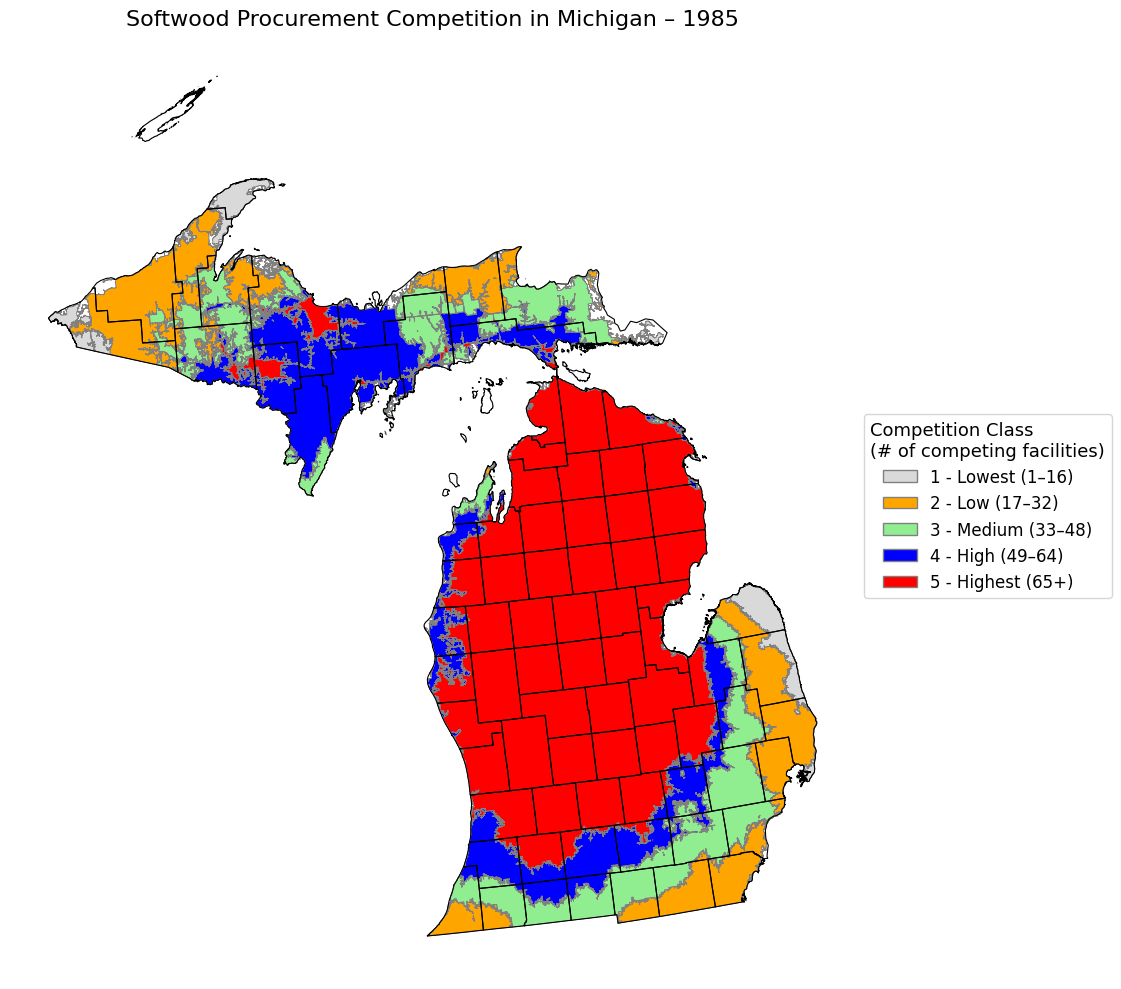

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set correct base path in Colab (after extracting the .7z archive)
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths for 1985 shapefiles (from GitHub, not local PC)
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_1985 = os.path.join(base_path, "Softwood_1985_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_1985 = gpd.read_file(hotspot_fp_1985)

# ✅ Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject 1985 hotspots to target CRS if needed
if gdf_hotspots_1985.crs != target_crs:
    gdf_hotspots_1985 = gdf_hotspots_1985.to_crs(target_crs)

# ✅ Check if 'CompValue' exists
if 'CompValue' not in gdf_hotspots_1985.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1985 hotspots shapefile!")

# ✅ Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Map colors to CompValue
gdf_hotspots_1985['color'] = gdf_hotspots_1985['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 1985 hotspots with color fill and grey edges
gdf_hotspots_1985.plot(ax=ax, color=gdf_hotspots_1985['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and clean up
ax.set_title("Softwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2019 Forest Cover Map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Use base_path from your earlier Colab setup
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Softwood_1985_hotspots.shp")

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105  # 1 sq meter = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            # Use "CompValue" or fallback label
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~551677.36 acres of forest cover.
   - White/Red/Jack Pine Group: 12015.48 acres
   - Spruce/Fir Group: 51845.72 acres
   - Oak/Hickory Group: 1714.29 acres
   - Elm/Ash/Cottonwood Group: 4308.89 acres
   - Maple/Beech/Birch Group: 402302.38 acres
   - Aspen/Birch Group: 79490.59 acres

✅ Polygon 'Low' contains ~2772826.98 acres of forest cover.
   - White/Red/Jack Pine Group: 171058.44 acres
   - Spruce/Fir Group: 378024.32 acres
   - Exotic Softwoods Group: 123.55 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 44679.67 acres
   - Elm/Ash/Cottonwood Group: 26625.56 acres
   - Maple/Beech/Birch Group: 1575927.58 acres
   - Aspen/Birch Group: 576372.41 acres

✅ Polygon 'Medium' contains ~2612980.93 acres of forest cover.
   - White/Red/Jack Pine Group: 274163.00 acres
   - Spruce/Fir Group: 706951.96 acres
   - Exotic Softwoods Group: 15.44 acres
   - Oak/Hickory Group: 50471.20 acres
   - Elm/Ash/Cottonwood Group: 39799.35 acres
   - Maple/Be

# Using 2001 Map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Softwood_1985_hotspots.shp"

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 443620.76 acres
Polygon CompValue 'Low' → Forest area: 2496817.94 acres
Polygon CompValue 'Medium' → Forest area: 2125993.12 acres
Polygon CompValue 'High' → Forest area: 2697672.64 acres
Polygon CompValue 'Highest' → Forest area: 7456844.00 acres


# Softwood 1994

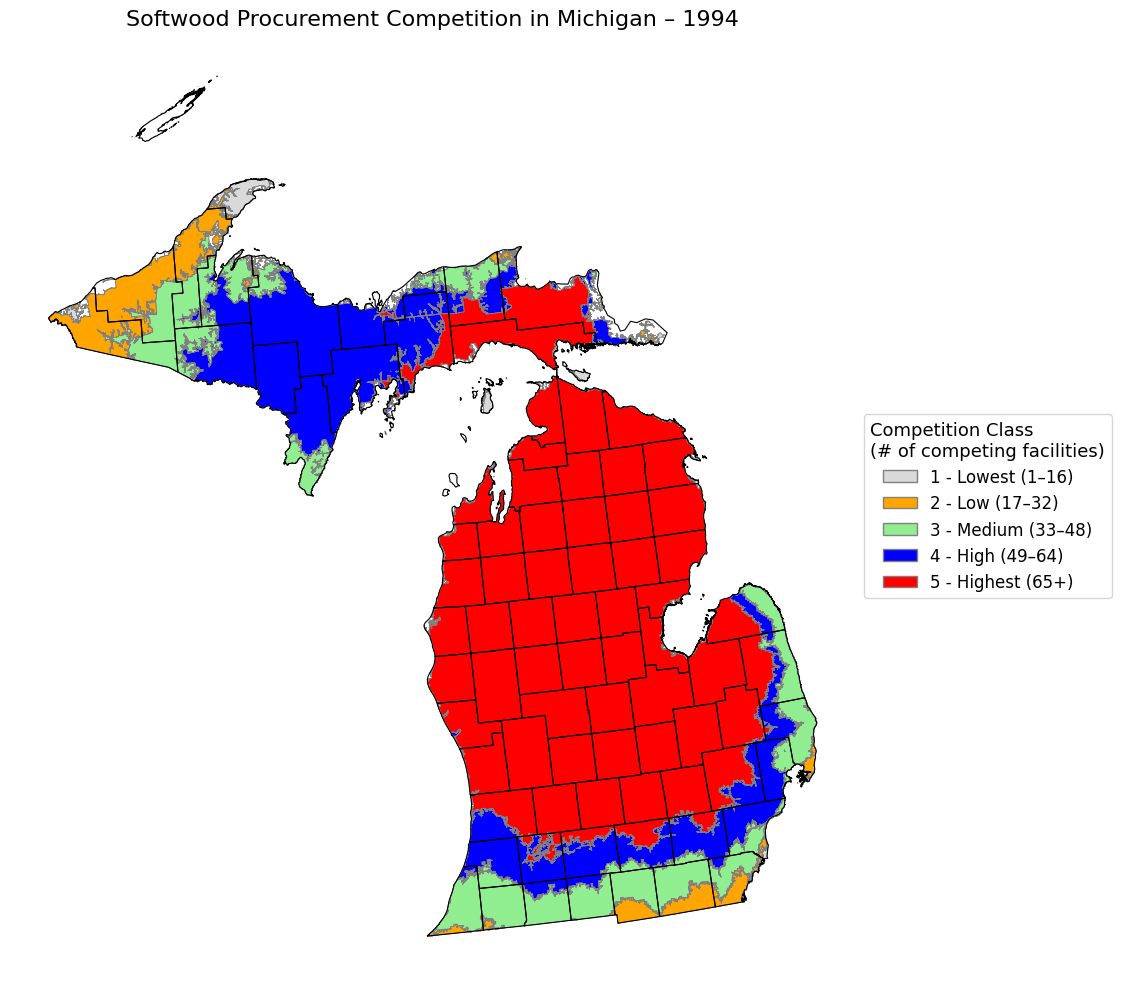

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Base path for extracted data in Colab
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths for Michigan counties and 1994 hotspots
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_1994 = os.path.join(base_path, "Softwood_1994_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_1994 = gpd.read_file(hotspot_fp_1994)

# ✅ Reproject both layers to ESRI:102010 if needed
target_crs = "ESRI:102010"

if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots_1994.crs != target_crs:
    gdf_hotspots_1994 = gdf_hotspots_1994.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_1994.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1994 hotspots shapefile!")

# ✅ Color mapping for competition levels
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Map colors to CompValue column
gdf_hotspots_1994['color'] = gdf_hotspots_1994['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot counties
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 1994 hotspots
gdf_hotspots_1994.plot(ax=ax, color=gdf_hotspots_1994['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Final touches
ax.set_title("Softwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [11]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Softwood_1994_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 185024.22 acres
Polygon CompValue 'Low' → Forest area: 1210470.36 acres
Polygon CompValue 'Medium' → Forest area: 1902535.13 acres
Polygon CompValue 'High' → Forest area: 3064730.09 acres
Polygon CompValue 'Highest' → Forest area: 8888146.53 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Use base_path from your Colab setup
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Softwood_1994_hotspots.shp")  # 🔹 Updated to 1994

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105  # 1 sq meter = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            # Use "CompValue" or fallback label
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~234209.21 acres of forest cover.
   - White/Red/Jack Pine Group: 3938.24 acres
   - Spruce/Fir Group: 28586.96 acres
   - Oak/Hickory Group: 1467.19 acres
   - Elm/Ash/Cottonwood Group: 2733.60 acres
   - Maple/Beech/Birch Group: 161730.22 acres
   - Aspen/Birch Group: 35753.00 acres

✅ Polygon 'Low' contains ~1353641.19 acres of forest cover.
   - White/Red/Jack Pine Group: 26347.57 acres
   - Spruce/Fir Group: 82270.52 acres
   - Exotic Softwoods Group: 123.55 acres
   - Oak/Hickory Group: 19104.31 acres
   - Elm/Ash/Cottonwood Group: 8108.13 acres
   - Maple/Beech/Birch Group: 1083632.65 acres
   - Aspen/Birch Group: 134054.46 acres

✅ Polygon 'Medium' contains ~2098261.22 acres of forest cover.
   - White/Red/Jack Pine Group: 141776.49 acres
   - Spruce/Fir Group: 301390.88 acres
   - Exotic Softwoods Group: 15.44 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 80401.79 acres
   - Elm/Ash/Cottonwood Group: 69204.84 acres
   - Maple/Beech/

# Softwood 2002

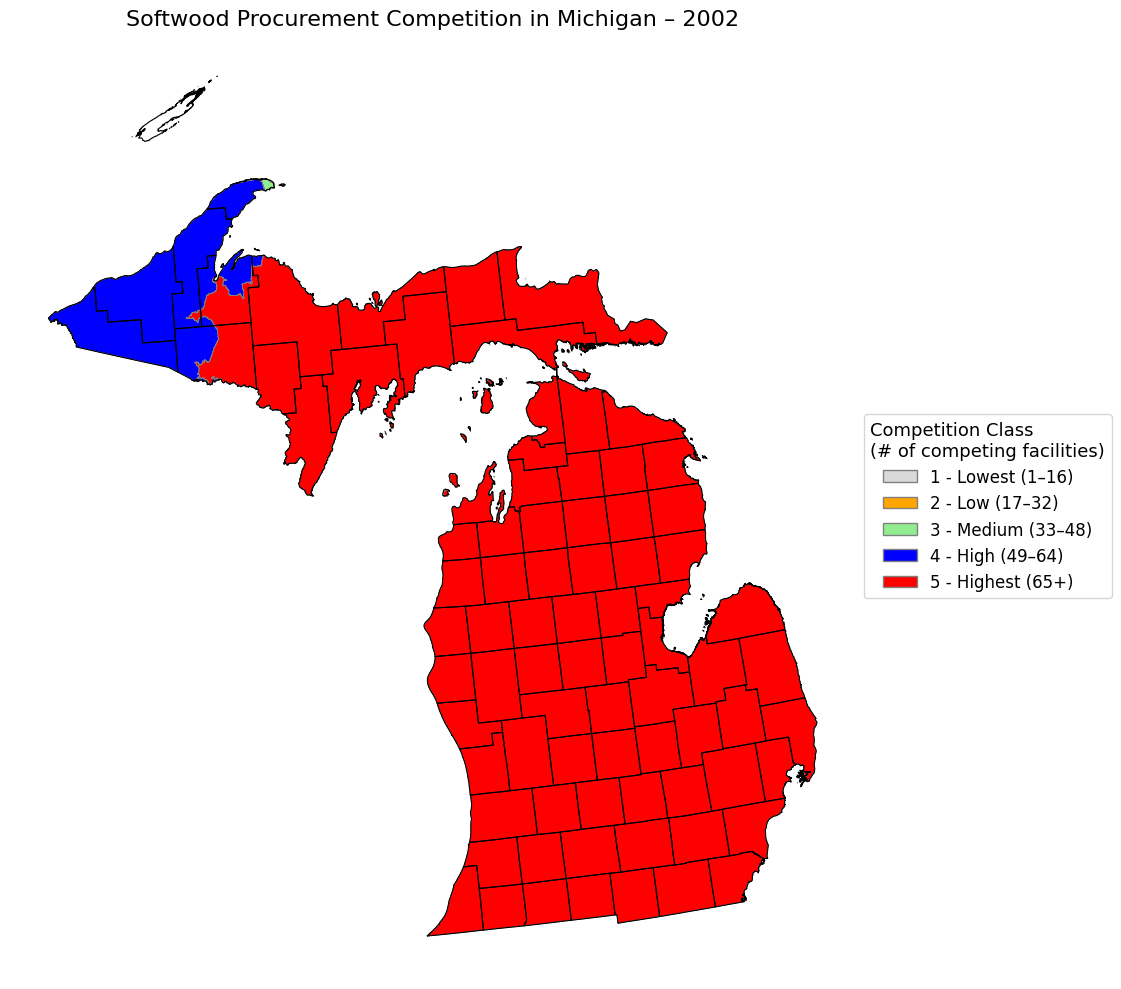

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Base data directory
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths for Michigan counties and 2002 hotspots
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2002 = os.path.join(base_path, "Softwood_2002_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2002 = gpd.read_file(hotspot_fp_2002)

# ✅ Reproject both to ESRI:102010
target_crs = "ESRI:102010"

if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots_2002.crs != target_crs:
    gdf_hotspots_2002 = gdf_hotspots_2002.to_crs(target_crs)

# ✅ Check if 'CompValue' exists
if 'CompValue' not in gdf_hotspots_2002.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2002 hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Map colors to each feature
gdf_hotspots_2002['color'] = gdf_hotspots_2002['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots with color
gdf_hotspots_2002.plot(ax=ax, color=gdf_hotspots_2002['color'], edgecolor='grey', linewidth=0.5)

# ✅ Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Final adjustments
ax.set_title("Softwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [13]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Softwood_2002_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 457.24 acres
Polygon CompValue 'Low' → Forest area: 1215.16 acres
Polygon CompValue 'Medium' → Forest area: 14483.66 acres
Polygon CompValue 'High' → Forest area: 2295806.89 acres
Polygon CompValue 'Highest' → Forest area: 13405577.51 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Softwood_2002_hotspots.shp")  # 🔹 Updated to 2002

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105  # 1 sq meter = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~0.00 acres of forest cover.

✅ Polygon 'Low' contains ~15.44 acres of forest cover.
   - Maple/Beech/Birch Group: 15.44 acres

✅ Polygon 'Medium' contains ~14934.41 acres of forest cover.
   - White/Red/Jack Pine Group: 61.78 acres
   - Spruce/Fir Group: 1127.42 acres
   - Oak/Hickory Group: 15.44 acres
   - Maple/Beech/Birch Group: 12849.46 acres
   - Aspen/Birch Group: 880.31 acres

✅ Polygon 'High' contains ~2758186.01 acres of forest cover.
   - White/Red/Jack Pine Group: 43861.14 acres
   - Spruce/Fir Group: 222935.04 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 2610.05 acres
   - Elm/Ash/Cottonwood Group: 12092.70 acres
   - Maple/Beech/Birch Group: 2196083.91 acres
   - Aspen/Birch Group: 280464.18 acres

✅ Polygon 'Highest' contains ~16105269.15 acres of forest cover.
   - White/Red/Jack Pine Group: 2391713.85 acres
   - Spruce/Fir Group: 3017105.72 acres
   - Oak/Pine Group: 30.89 acres
   - Oak/Hickory Group: 151676.14 a

# Softwood 2018

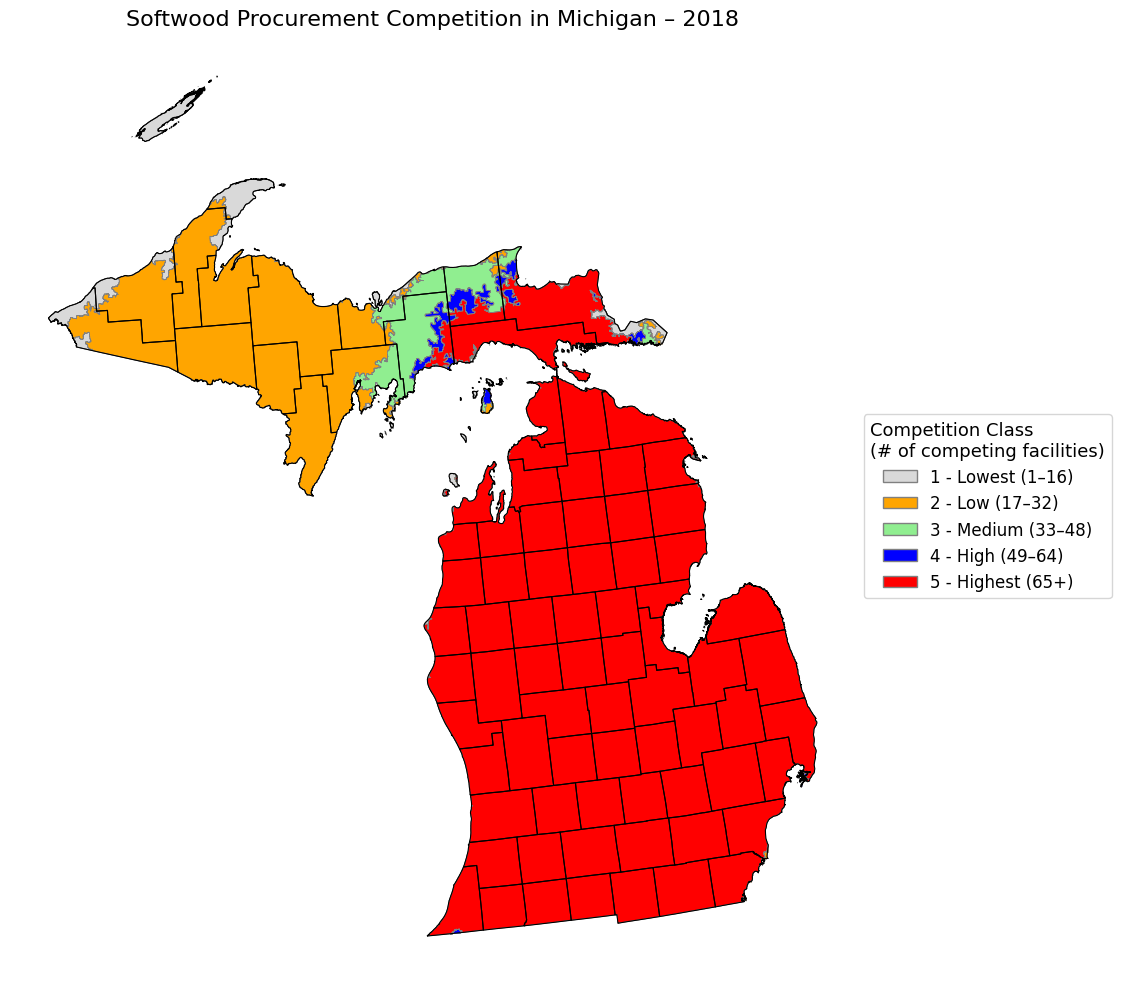

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path to the data folder
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2018 = os.path.join(base_path, "Softwood_2018_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2018 = gpd.read_file(hotspot_fp_2018)

# ✅ Reproject to ESRI:102010 if necessary
target_crs = "ESRI:102010"

if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots_2018.crs != target_crs:
    gdf_hotspots_2018 = gdf_hotspots_2018.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_2018.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2018 hotspots shapefile!")

# ✅ Define color mapping
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping to each feature
gdf_hotspots_2018['color'] = gdf_hotspots_2018['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspot polygons
gdf_hotspots_2018.plot(ax=ax, color=gdf_hotspots_2018['color'], edgecolor='grey', linewidth=0.5)

# ✅ Create legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Final plot settings
ax.set_title("Softwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [15]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Softwood_2018_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 588361.33 acres
Polygon CompValue 'Low' → Forest area: 4052679.63 acres
Polygon CompValue 'Medium' → Forest area: 677761.47 acres
Polygon CompValue 'High' → Forest area: 158821.92 acres
Polygon CompValue 'Highest' → Forest area: 10338641.49 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Softwood_2018_hotspots.shp")  # 🔹 Updated to 2018

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~669114.01 acres of forest cover.
   - White/Red/Jack Pine Group: 13281.89 acres
   - Spruce/Fir Group: 65374.72 acres
   - Oak/Hickory Group: 1250.97 acres
   - Elm/Ash/Cottonwood Group: 4046.34 acres
   - Maple/Beech/Birch Group: 467460.88 acres
   - Aspen/Birch Group: 117699.20 acres

✅ Polygon 'Low' contains ~5871276.58 acres of forest cover.
   - White/Red/Jack Pine Group: 214317.26 acres
   - Spruce/Fir Group: 1347000.24 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 8648.68 acres
   - Elm/Ash/Cottonwood Group: 41791.63 acres
   - Maple/Beech/Birch Group: 3411361.75 acres
   - Aspen/Birch Group: 848018.03 acres

✅ Polygon 'Medium' contains ~1155246.76 acres of forest cover.
   - White/Red/Jack Pine Group: 279135.99 acres
   - Spruce/Fir Group: 458642.32 acres
   - Oak/Hickory Group: 4216.23 acres
   - Elm/Ash/Cottonwood Group: 6007.74 acres
   - Maple/Beech/Birch Group: 122054.43 acres
   - Aspen/Birch Group: 285190.06 acres

✅

# Softwood 2023

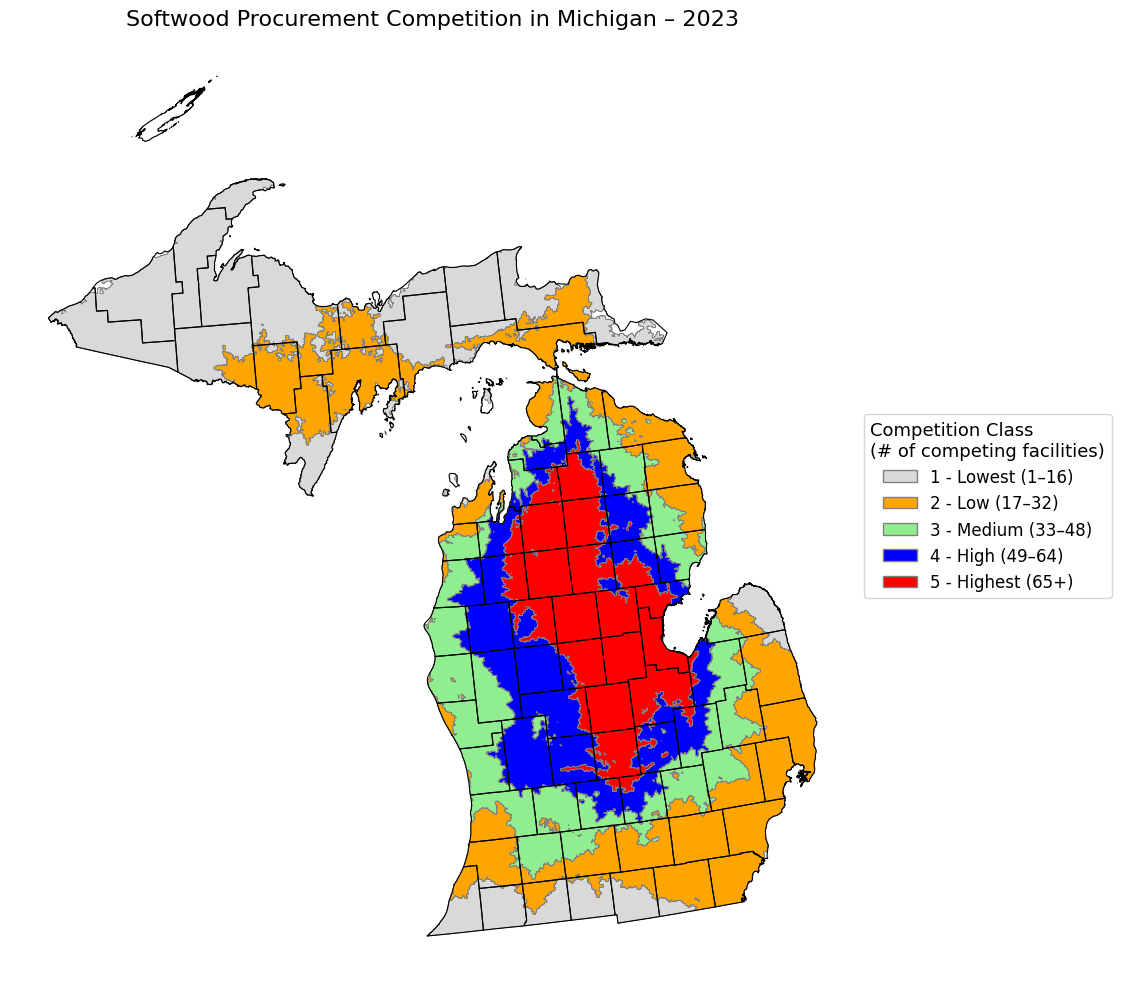

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path to the extracted shapefiles
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2023 = os.path.join(base_path, "Softwood_2023_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2023 = gpd.read_file(hotspot_fp_2023)

# ✅ Reproject to ESRI:102010 if needed
target_crs = "ESRI:102010"

if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots_2023.crs != target_crs:
    gdf_hotspots_2023 = gdf_hotspots_2023.to_crs(target_crs)

# ✅ Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots_2023.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2023 hotspots shapefile!")

# ✅ Color mapping for competition levels
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Map colors to CompValue
gdf_hotspots_2023['color'] = gdf_hotspots_2023['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 2023 hotspots
gdf_hotspots_2023.plot(ax=ax, color=gdf_hotspots_2023['color'], edgecolor='grey', linewidth=0.5)

# ✅ Create custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Final touches
ax.set_title("Softwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [17]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Softwood_2023_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 4914581.74 acres
Polygon CompValue 'Low' → Forest area: 3366740.71 acres
Polygon CompValue 'Medium' → Forest area: 2632102.29 acres
Polygon CompValue 'High' → Forest area: 2498584.42 acres
Polygon CompValue 'Highest' → Forest area: 2163349.84 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Softwood_2023_hotspots.shp")  # 🔹 Updated to 2023

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~6814877.91 acres of forest cover.
   - White/Red/Jack Pine Group: 578009.48 acres
   - Spruce/Fir Group: 1572761.55 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Pine Group: 30.89 acres
   - Oak/Hickory Group: 88062.04 acres
   - Elm/Ash/Cottonwood Group: 82038.86 acres
   - Maple/Beech/Birch Group: 3215144.93 acres
   - Aspen/Birch Group: 1278691.15 acres

✅ Polygon 'Low' contains ~4383024.94 acres of forest cover.
   - White/Red/Jack Pine Group: 255027.80 acres
   - Spruce/Fir Group: 1189316.36 acres
   - Oak/Hickory Group: 49235.67 acres
   - Elm/Ash/Cottonwood Group: 81266.66 acres
   - Maple/Beech/Birch Group: 781917.44 acres
   - Aspen/Birch Group: 2026261.00 acres

✅ Polygon 'Medium' contains ~2552301.21 acres of forest cover.
   - White/Red/Jack Pine Group: 440619.10 acres
   - Spruce/Fir Group: 148726.32 acres
   - Oak/Hickory Group: 15474.95 acres
   - Elm/Ash/Cottonwood Group: 14918.96 acres
   - Maple/Beech/Birch Group: 16278.04 acres

# Hardwood

# Hardwood 1985

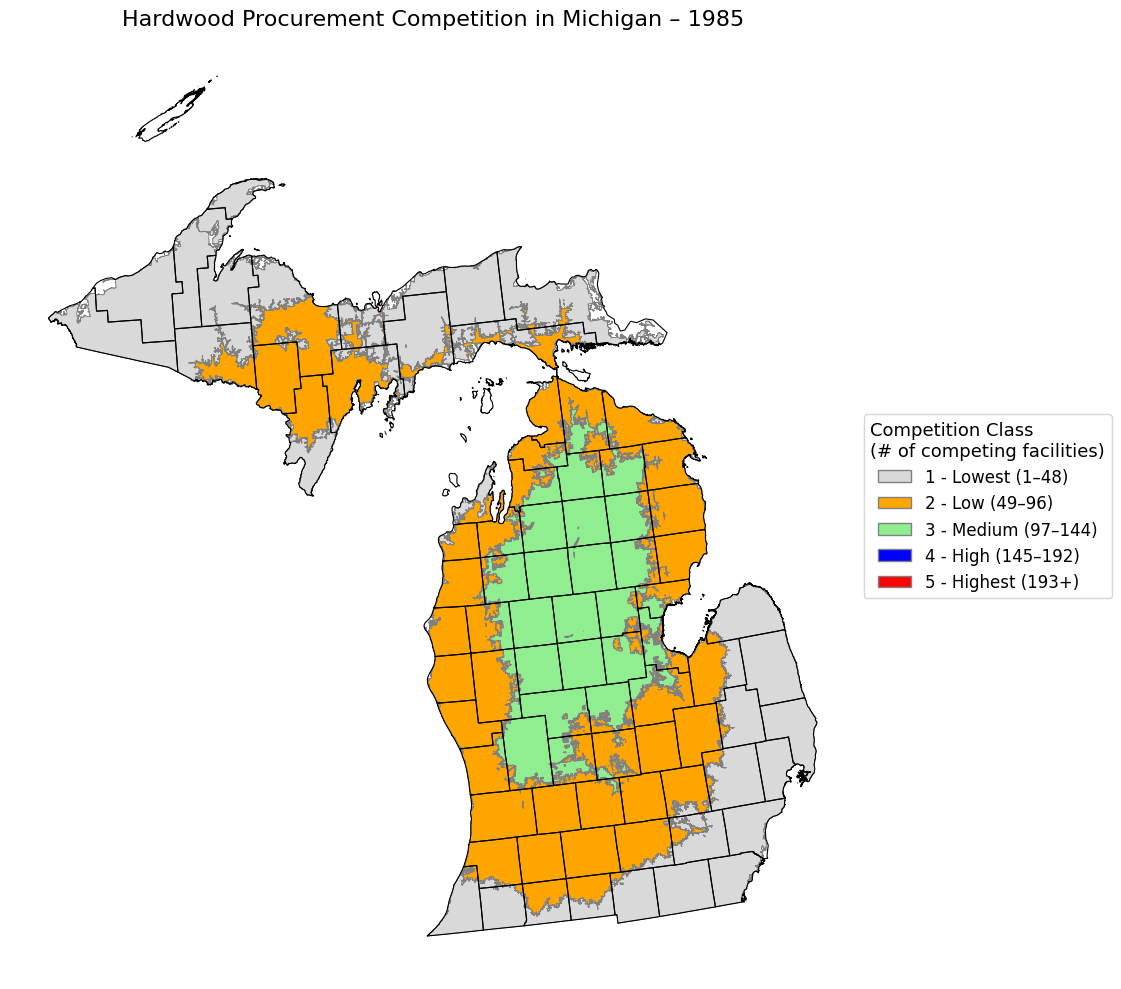

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_1985 = os.path.join(base_path, "Hardwood_1985_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_1985 = gpd.read_file(hotspot_fp_1985)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Hardwood 1985 hotspots
if gdf_hotspots_1985.crs != target_crs:
    gdf_hotspots_1985 = gdf_hotspots_1985.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_1985.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1985 Hardwood hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping
gdf_hotspots_1985['color'] = gdf_hotspots_1985['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood hotspots
gdf_hotspots_1985.plot(ax=ax, color=gdf_hotspots_1985['color'], edgecolor='grey', linewidth=0.5)

# ✅ Updated legend elements for Hardwood
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# ✅ Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [17]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Hardwood_1985_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Hardwood_1985_hotspots.shp")  # 🔹 Updated to Hardwood 1985

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~7249427.49 acres of forest cover.
   - White/Red/Jack Pine Group: 568125.28 acres
   - Spruce/Fir Group: 1613765.53 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 93621.91 acres
   - Elm/Ash/Cottonwood Group: 73328.41 acres
   - Maple/Beech/Birch Group: 3078557.64 acres
   - Aspen/Birch Group: 1821874.28 acres

✅ Polygon 'Low' contains ~7200037.38 acres of forest cover.
   - White/Red/Jack Pine Group: 913763.40 acres
   - Spruce/Fir Group: 1249023.11 acres
   - Oak/Hickory Group: 58949.99 acres
   - Elm/Ash/Cottonwood Group: 101421.16 acres
   - Maple/Beech/Birch Group: 790797.78 acres
   - Aspen/Birch Group: 4086081.95 acres

✅ Polygon 'Medium' contains ~3863409.45 acres of forest cover.
   - White/Red/Jack Pine Group: 905269.17 acres
   - Spruce/Fir Group: 235259.40 acres
   - Oak/Hickory Group: 401.55 acres
   - Elm/Ash/Cottonwood Group: 1158.30 acres
   - Maple/Beech/Birch Group: 15.44 acres
   -

# Hardwood 1994

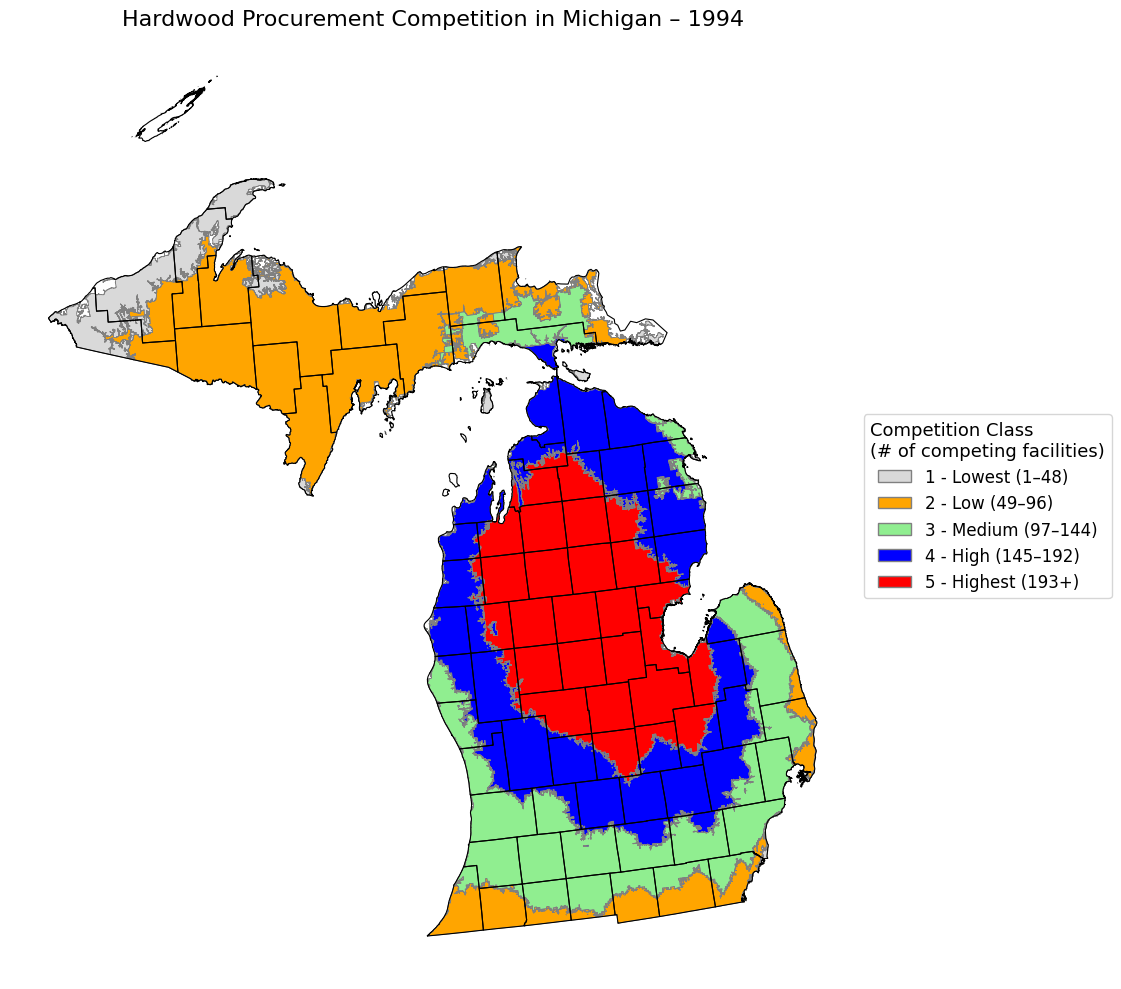

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_1994 = os.path.join(base_path, "Hardwood_1994_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_1994 = gpd.read_file(hotspot_fp_1994)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Hardwood 1994 hotspots
if gdf_hotspots_1994.crs != target_crs:
    gdf_hotspots_1994 = gdf_hotspots_1994.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_1994.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1994 Hardwood hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping
gdf_hotspots_1994['color'] = gdf_hotspots_1994['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood hotspots
gdf_hotspots_1994.plot(ax=ax, color=gdf_hotspots_1994['color'], edgecolor='grey', linewidth=0.5)

# ✅ Updated legend elements for Hardwood
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# ✅ Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [19]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Hardwood_1994_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 1362602.65 acres
Polygon CompValue 'Low' → Forest area: 4363262.00 acres
Polygon CompValue 'Medium' → Forest area: 1996841.96 acres
Polygon CompValue 'High' → Forest area: 3895163.16 acres
Polygon CompValue 'Highest' → Forest area: 3633352.35 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Hardwood_1994_hotspots.shp")  # 🔹 Updated to Hardwood 1994

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~1634522.35 acres of forest cover.
   - White/Red/Jack Pine Group: 43505.92 acres
   - Spruce/Fir Group: 122054.43 acres
   - Exotic Softwoods Group: 123.55 acres
   - Oak/Hickory Group: 2270.28 acres
   - Elm/Ash/Cottonwood Group: 8710.45 acres
   - Maple/Beech/Birch Group: 1313563.85 acres
   - Aspen/Birch Group: 144293.88 acres

✅ Polygon 'Low' contains ~6626939.11 acres of forest cover.
   - White/Red/Jack Pine Group: 551970.79 acres
   - Spruce/Fir Group: 2030477.23 acres
   - Exotic Softwoods Group: 15.44 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 83413.38 acres
   - Elm/Ash/Cottonwood Group: 72926.86 acres
   - Maple/Beech/Birch Group: 2490555.85 acres
   - Aspen/Birch Group: 1397564.10 acres

✅ Polygon 'Medium' contains ~2000870.96 acres of forest cover.
   - White/Red/Jack Pine Group: 159691.61 acres
   - Spruce/Fir Group: 365916.17 acres
   - Oak/Hickory Group: 65544.60 acres
   - Elm/Ash/Cottonwood Group: 92695.26 acres
   - Ma

# Hardwood 2002

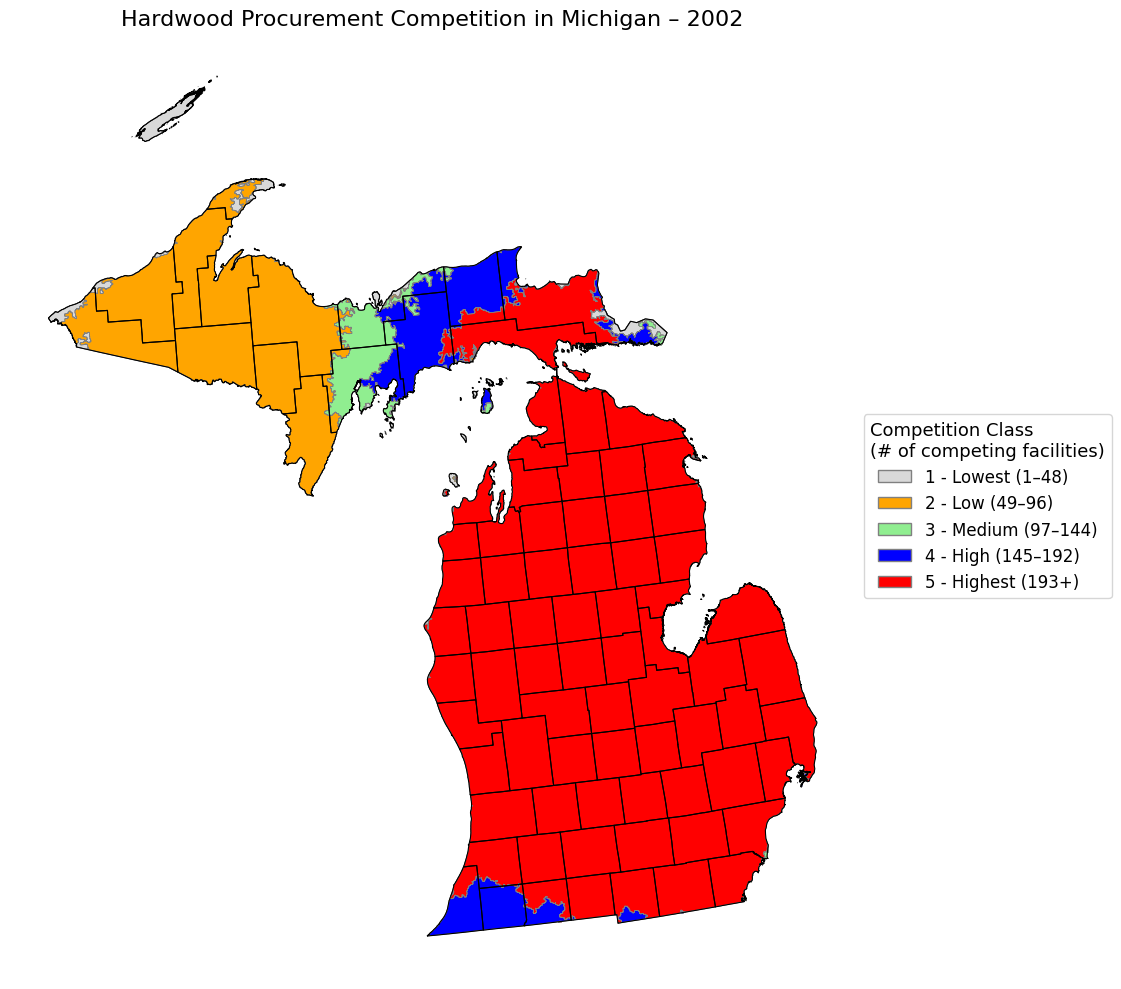

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2002 = os.path.join(base_path, "Hardwood_2002_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2002 = gpd.read_file(hotspot_fp_2002)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Hardwood 2002 hotspots
if gdf_hotspots_2002.crs != target_crs:
    gdf_hotspots_2002 = gdf_hotspots_2002.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_2002.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2002 Hardwood hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping
gdf_hotspots_2002['color'] = gdf_hotspots_2002['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood hotspots
gdf_hotspots_2002.plot(ax=ax, color=gdf_hotspots_2002['color'], edgecolor='grey', linewidth=0.5)

# ✅ Updated legend elements for Hardwood
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# ✅ Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [21]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Hardwood_2002_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 320823.64 acres
Polygon CompValue 'Low' → Forest area: 3921612.99 acres
Polygon CompValue 'Medium' → Forest area: 471257.50 acres
Polygon CompValue 'High' → Forest area: 993285.00 acres
Polygon CompValue 'Highest' → Forest area: 10109198.42 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Hardwood_2002_hotspots.shp")  # 🔹 Updated to Hardwood 2002

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~353576.37 acres of forest cover.
   - White/Red/Jack Pine Group: 11057.95 acres
   - Spruce/Fir Group: 49297.45 acres
   - Oak/Hickory Group: 139.00 acres
   - Elm/Ash/Cottonwood Group: 1884.18 acres
   - Maple/Beech/Birch Group: 182749.59 acres
   - Aspen/Birch Group: 108448.21 acres

✅ Polygon 'Low' contains ~5467785.00 acres of forest cover.
   - White/Red/Jack Pine Group: 153791.97 acres
   - Spruce/Fir Group: 1113980.23 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 8525.12 acres
   - Elm/Ash/Cottonwood Group: 34795.47 acres
   - Maple/Beech/Birch Group: 3402574.07 acres
   - Aspen/Birch Group: 753979.13 acres

✅ Polygon 'Medium' contains ~835925.33 acres of forest cover.
   - White/Red/Jack Pine Group: 79135.38 acres
   - Spruce/Fir Group: 280711.28 acres
   - Oak/Hickory Group: 1637.07 acres
   - Elm/Ash/Cottonwood Group: 11490.38 acres
   - Maple/Beech/Birch Group: 329545.41 acres
   - Aspen/Birch Group: 133405.81 acres

✅ P

# Hardwood 2018

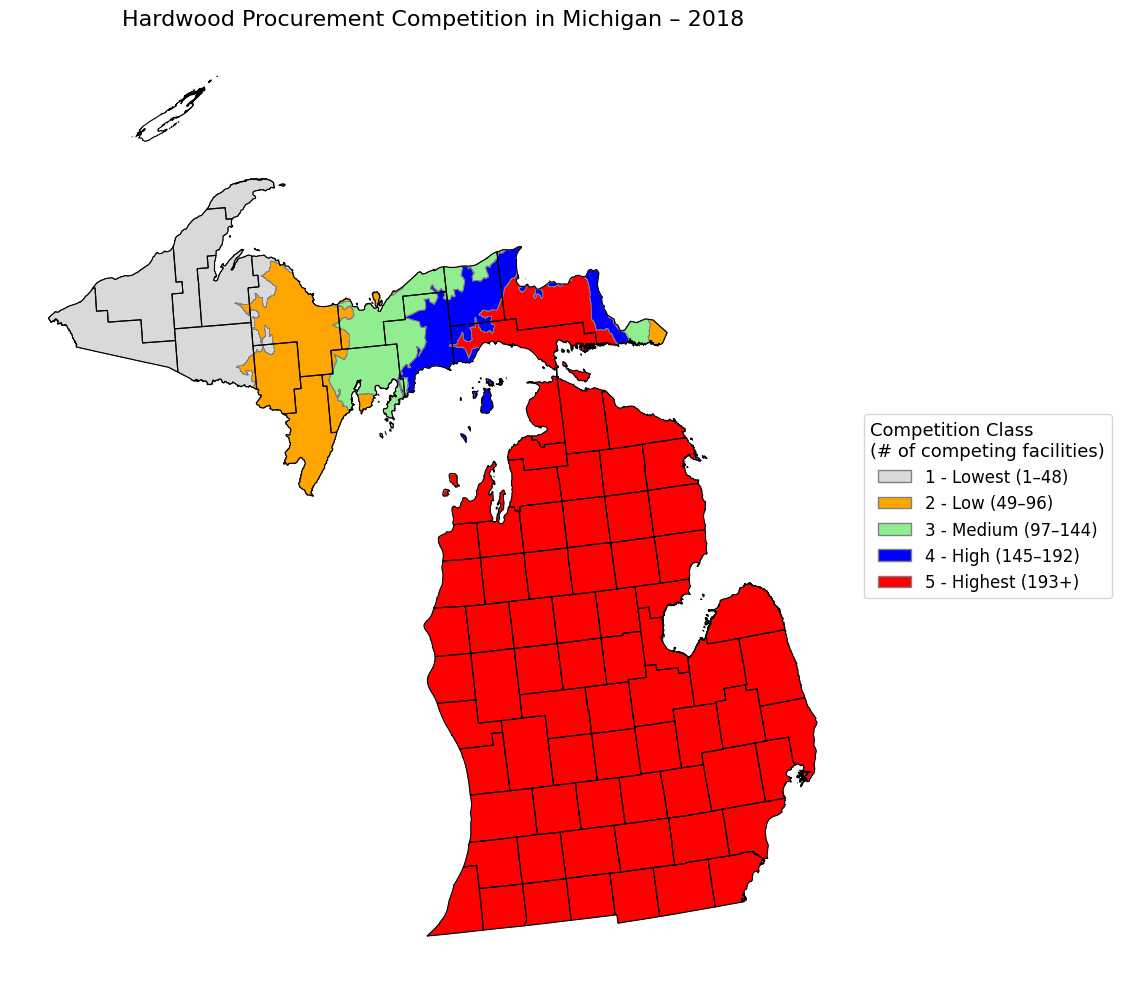

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2018 = os.path.join(base_path, "Hardwood_2018_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2018 = gpd.read_file(hotspot_fp_2018)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Hardwood 2018 hotspots
if gdf_hotspots_2018.crs != target_crs:
    gdf_hotspots_2018 = gdf_hotspots_2018.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_2018.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2018 Hardwood hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping
gdf_hotspots_2018['color'] = gdf_hotspots_2018['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood hotspots
gdf_hotspots_2018.plot(ax=ax, color=gdf_hotspots_2018['color'], edgecolor='grey', linewidth=0.5)

# ✅ Updated legend elements for Hardwood
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# ✅ Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [23]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Hardwood_2018_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 2919835.85 acres
Polygon CompValue 'Low' → Forest area: 1207639.72 acres
Polygon CompValue 'Medium' → Forest area: 845886.82 acres
Polygon CompValue 'High' → Forest area: 571564.54 acres
Polygon CompValue 'Highest' → Forest area: 10172613.54 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Hardwood_2018_hotspots.shp")  # 🔹 Updated to Hardwood 2018

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~3638018.81 acres of forest cover.
   - White/Red/Jack Pine Group: 66100.59 acres
   - Spruce/Fir Group: 412866.12 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 3413.14 acres
   - Elm/Ash/Cottonwood Group: 13791.55 acres
   - Maple/Beech/Birch Group: 2727344.22 acres
   - Aspen/Birch Group: 414364.20 acres

✅ Polygon 'Low' contains ~2121705.31 acres of forest cover.
   - White/Red/Jack Pine Group: 91197.19 acres
   - Spruce/Fir Group: 763137.46 acres
   - Oak/Hickory Group: 5297.31 acres
   - Elm/Ash/Cottonwood Group: 28216.30 acres
   - Maple/Beech/Birch Group: 869825.04 acres
   - Aspen/Birch Group: 364032.00 acres

✅ Polygon 'Medium' contains ~1438954.19 acres of forest cover.
   - White/Red/Jack Pine Group: 246734.34 acres
   - Spruce/Fir Group: 516866.44 acres
   - Oak/Hickory Group: 3274.14 acres
   - Elm/Ash/Cottonwood Group: 9281.88 acres
   - Maple/Beech/Birch Group: 356448.96 acres
   - Aspen/Birch Group: 306348.42 acres



# Hardwood 2023

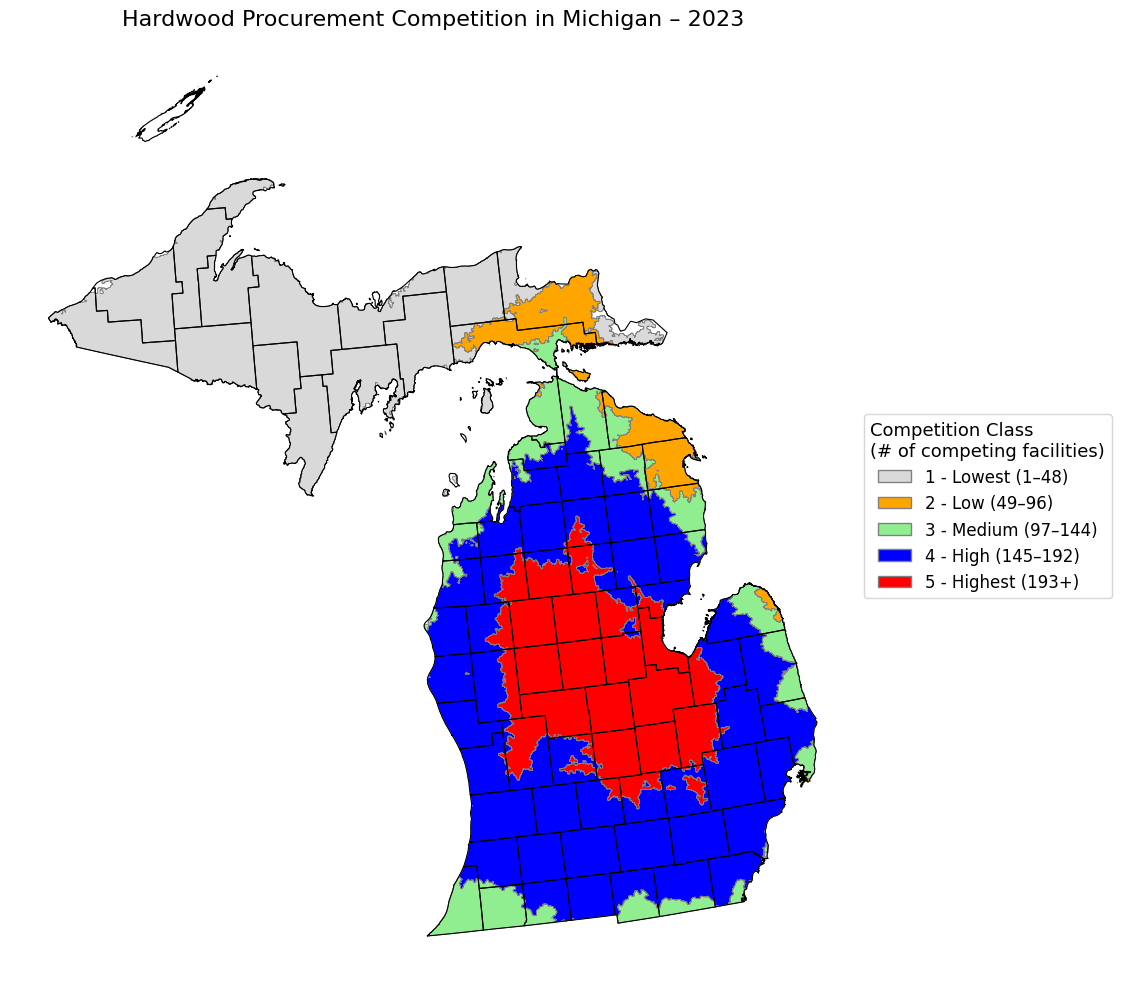

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_2023 = os.path.join(base_path, "Hardwood_2023_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2023 = gpd.read_file(hotspot_fp_2023)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Hardwood 2023 hotspots
if gdf_hotspots_2023.crs != target_crs:
    gdf_hotspots_2023 = gdf_hotspots_2023.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_2023.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2023 Hardwood hotspots shapefile!")

# ✅ Define color map
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# ✅ Apply color mapping
gdf_hotspots_2023['color'] = gdf_hotspots_2023['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood hotspots
gdf_hotspots_2023.plot(ax=ax, color=gdf_hotspots_2023['color'], edgecolor='grey', linewidth=0.5)

# ✅ Updated legend elements for Hardwood ranges
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# ✅ Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# ✅ Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Using 2001 Map

In [25]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Hardwood_2023_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 5501789.29 acres
Polygon CompValue 'Low' → Forest area: 771532.56 acres
Polygon CompValue 'Medium' → Forest area: 1435339.89 acres
Polygon CompValue 'High' → Forest area: 5847988.81 acres
Polygon CompValue 'Highest' → Forest area: 2041001.51 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Hardwood_2023_hotspots.shp")  # 🔹 Updated to Hardwood 2023

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~8235376.44 acres of forest cover.
   - White/Red/Jack Pine Group: 577329.94 acres
   - Spruce/Fir Group: 2159867.58 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 14084.99 acres
   - Elm/Ash/Cottonwood Group: 51644.95 acres
   - Maple/Beech/Birch Group: 3930622.01 acres
   - Aspen/Birch Group: 1501687.97 acres

✅ Polygon 'Low' contains ~1354475.17 acres of forest cover.
   - White/Red/Jack Pine Group: 136386.52 acres
   - Spruce/Fir Group: 495986.07 acres
   - Aspen/Birch Group: 722102.59 acres

✅ Polygon 'Medium' contains ~1618584.08 acres of forest cover.
   - White/Red/Jack Pine Group: 207490.98 acres
   - Spruce/Fir Group: 221591.41 acres
   - Oak/Pine Group: 30.89 acres
   - Oak/Hickory Group: 61050.38 acres
   - Elm/Ash/Cottonwood Group: 28293.52 acres
   - Maple/Beech/Birch Group: 17158.35 acres
   - Aspen/Birch Group: 1082968.55 acres

✅ Polygon 'High' contains ~5518456.97 acres of forest cover.
   - White/Red/Jack Pine Grou

# Biomass

# Biomass 1985

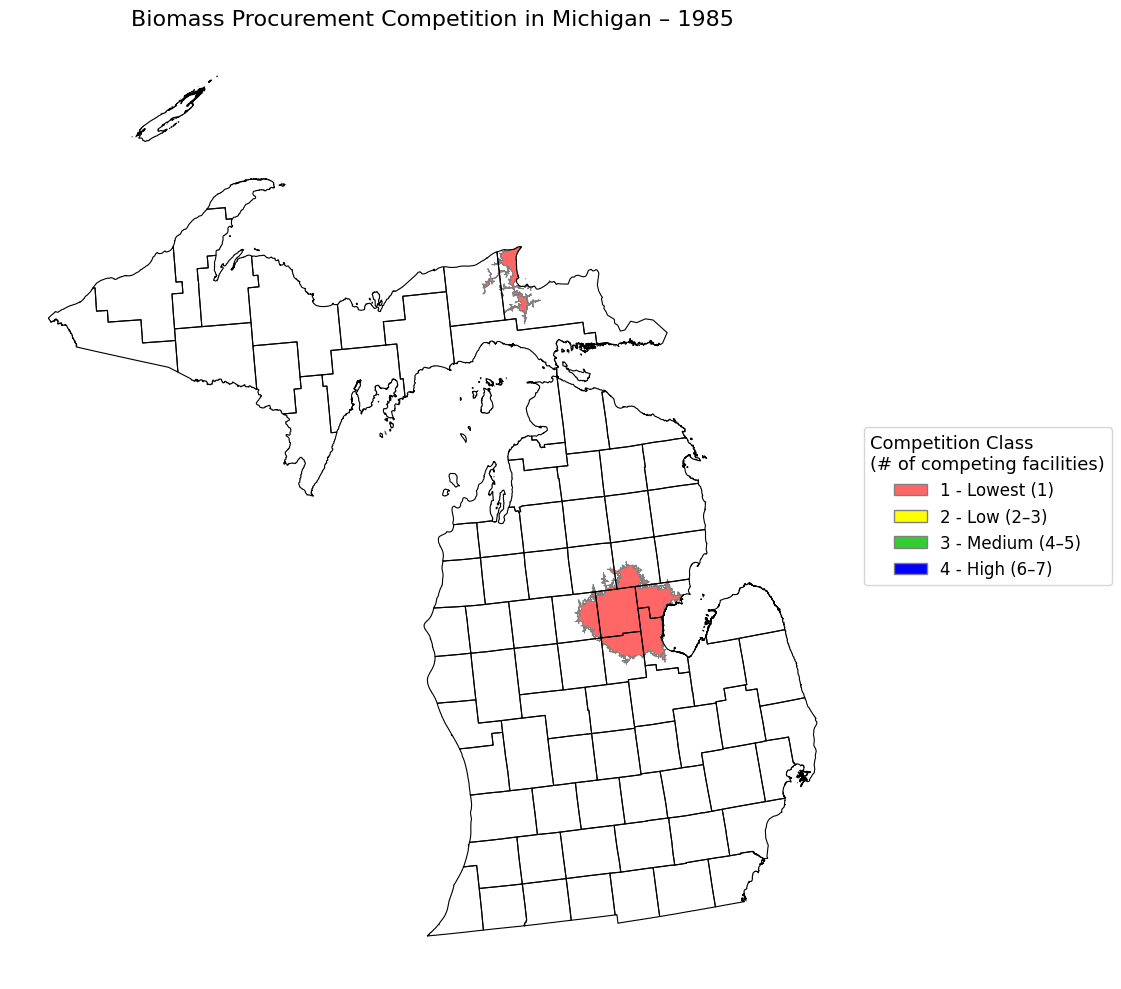

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_biomass_1985 = os.path.join(base_path, "Biomass_1985_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_biomass_1985 = gpd.read_file(hotspot_fp_biomass_1985)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Biomass 1985 hotspots
if gdf_hotspots_biomass_1985.crs != target_crs:
    gdf_hotspots_biomass_1985 = gdf_hotspots_biomass_1985.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_biomass_1985.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1985 Biomass hotspots shapefile!")

# ✅ Color mapping for biomass classes
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_biomass_1985['color'] = gdf_hotspots_biomass_1985['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Biomass 1985 hotspots
gdf_hotspots_biomass_1985.plot(ax=ax, color=gdf_hotspots_biomass_1985['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for biomass classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Biomass Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [27]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Biomass_1985_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 369772.67 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Biomass_1985_hotspots.shp")  # 🔹 Updated to Biomass 1985

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~579121.46 acres of forest cover.
   - White/Red/Jack Pine Group: 71645.01 acres
   - Spruce/Fir Group: 32247.20 acres
   - Oak/Hickory Group: 92.66 acres
   - Aspen/Birch Group: 475136.58 acres



# Biomass 1994

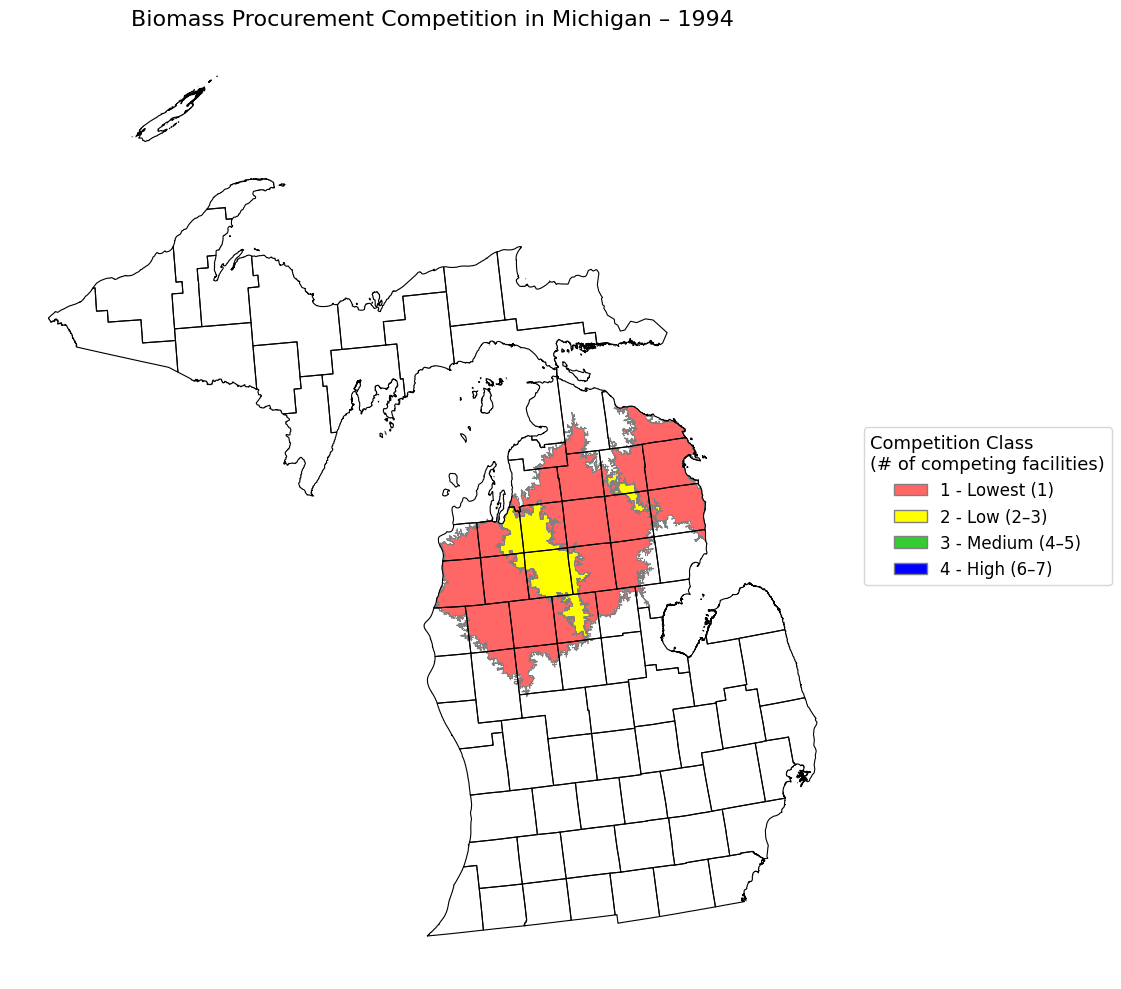

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_biomass_1994 = os.path.join(base_path, "Biomass_1994_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_biomass_1994 = gpd.read_file(hotspot_fp_biomass_1994)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Biomass 1994 hotspots
if gdf_hotspots_biomass_1994.crs != target_crs:
    gdf_hotspots_biomass_1994 = gdf_hotspots_biomass_1994.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_biomass_1994.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1994 Biomass hotspots shapefile!")

# ✅ Color mapping for biomass classes
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_biomass_1994['color'] = gdf_hotspots_biomass_1994['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Biomass 1994 hotspots
gdf_hotspots_biomass_1994.plot(ax=ax, color=gdf_hotspots_biomass_1994['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for biomass classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Biomass Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [30]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Biomass_1994_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 3484469.24 acres
Polygon CompValue 'Low' → Forest area: 571087.28 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Biomass_1994_hotspots.shp")  # 🔹 Updated to Biomass 1994

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~4102622.54 acres of forest cover.
   - White/Red/Jack Pine Group: 1017871.83 acres
   - Spruce/Fir Group: 369591.86 acres
   - Elm/Ash/Cottonwood Group: 864.87 acres
   - Aspen/Birch Group: 2714293.98 acres

✅ Polygon 'Low' contains ~671646.83 acres of forest cover.
   - White/Red/Jack Pine Group: 157884.65 acres
   - Spruce/Fir Group: 46579.29 acres
   - Elm/Ash/Cottonwood Group: 416.99 acres
   - Aspen/Birch Group: 466765.90 acres



# Biomass 2002

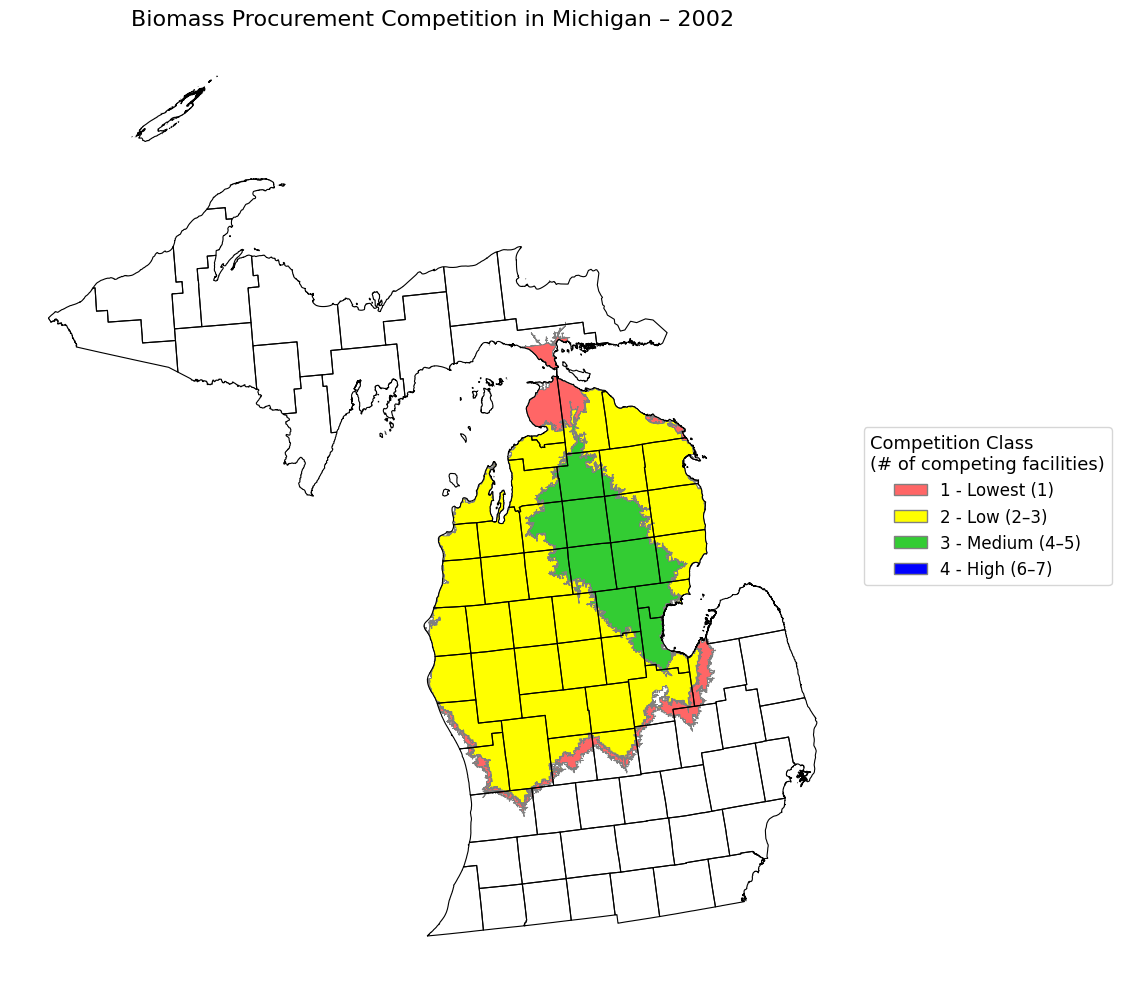

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_biomass_2002 = os.path.join(base_path, "Biomass_2002_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_biomass_2002 = gpd.read_file(hotspot_fp_biomass_2002)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Biomass 2002 hotspots
if gdf_hotspots_biomass_2002.crs != target_crs:
    gdf_hotspots_biomass_2002 = gdf_hotspots_biomass_2002.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_biomass_2002.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2002 Biomass hotspots shapefile!")

# ✅ Color mapping for biomass classes
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_biomass_2002['color'] = gdf_hotspots_biomass_2002['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Biomass 2002 hotspots
gdf_hotspots_biomass_2002.plot(ax=ax, color=gdf_hotspots_biomass_2002['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for biomass classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Biomass Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [32]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Biomass_2002_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 377002.93 acres
Polygon CompValue 'Low' → Forest area: 4861666.53 acres
Polygon CompValue 'Medium' → Forest area: 1625338.85 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Biomass_2002_hotspots.shp")  # 🔹 Updated to Biomass 2002

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~395151.78 acres of forest cover.
   - White/Red/Jack Pine Group: 23814.74 acres
   - Spruce/Fir Group: 80309.12 acres
   - Oak/Hickory Group: 200.77 acres
   - Elm/Ash/Cottonwood Group: 30.89 acres
   - Aspen/Birch Group: 290796.25 acres

✅ Polygon 'Low' contains ~5649005.63 acres of forest cover.
   - White/Red/Jack Pine Group: 1152760.27 acres
   - Spruce/Fir Group: 449514.88 acres
   - Oak/Hickory Group: 911.20 acres
   - Elm/Ash/Cottonwood Group: 1034.75 acres
   - Maple/Beech/Birch Group: 92.66 acres
   - Aspen/Birch Group: 4044691.86 acres

✅ Polygon 'Medium' contains ~1990585.22 acres of forest cover.
   - White/Red/Jack Pine Group: 510642.48 acres
   - Spruce/Fir Group: 145930.95 acres
   - Oak/Hickory Group: 61.78 acres
   - Elm/Ash/Cottonwood Group: 494.21 acres
   - Aspen/Birch Group: 1333455.80 acres



# Biomass 2018

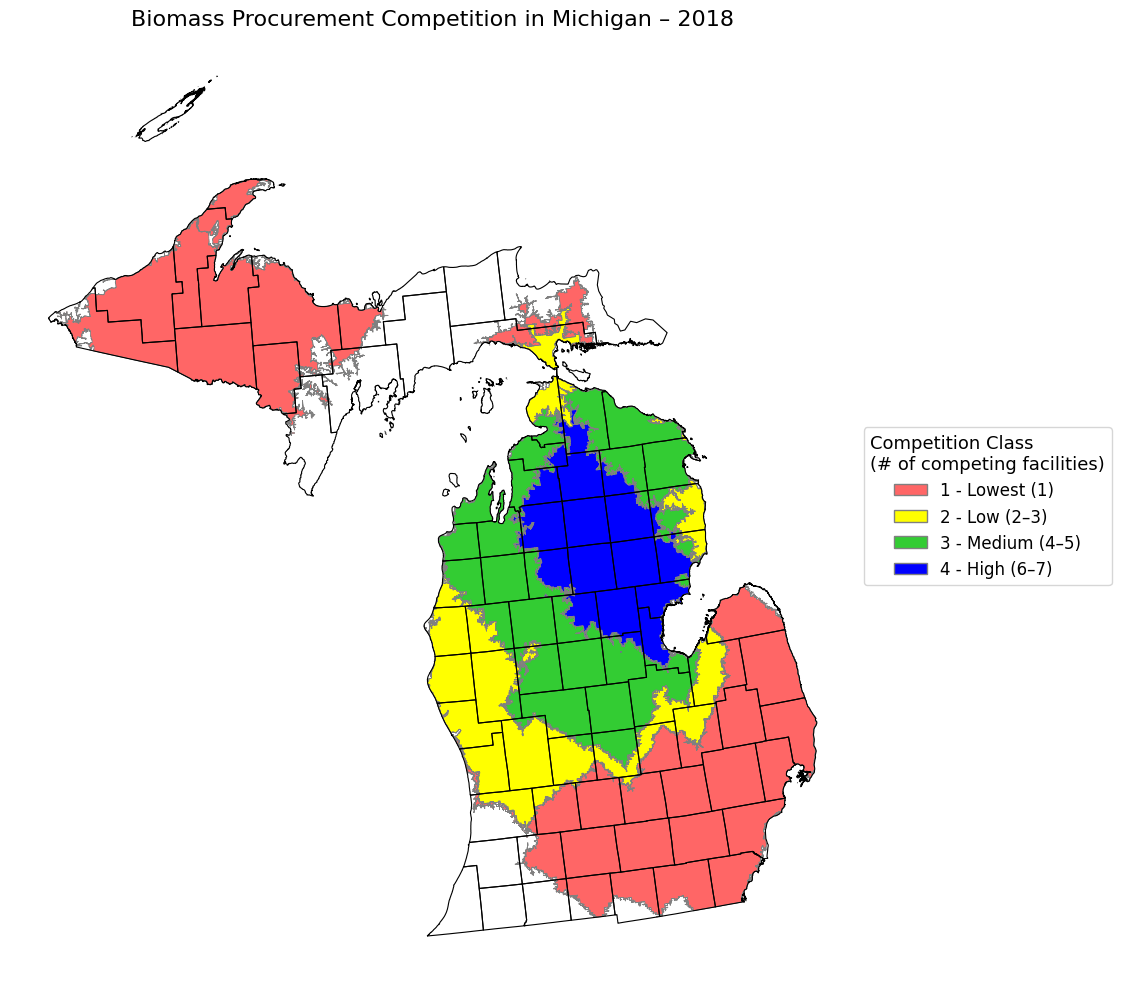

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_biomass_2018 = os.path.join(base_path, "Biomass_2018_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_biomass_2018 = gpd.read_file(hotspot_fp_biomass_2018)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Biomass 2018 hotspots
if gdf_hotspots_biomass_2018.crs != target_crs:
    gdf_hotspots_biomass_2018 = gdf_hotspots_biomass_2018.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_biomass_2018.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2018 Biomass hotspots shapefile!")

# ✅ Color mapping for biomass classes
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_biomass_2018['color'] = gdf_hotspots_biomass_2018['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Biomass 2018 hotspots
gdf_hotspots_biomass_2018.plot(ax=ax, color=gdf_hotspots_biomass_2018['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for biomass classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Biomass Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [34]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Biomass_2018_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 5846523.23 acres
Polygon CompValue 'Low' → Forest area: 1882244.08 acres
Polygon CompValue 'Medium' → Forest area: 2899905.97 acres
Polygon CompValue 'High' → Forest area: 2362857.27 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Biomass_2018_hotspots.shp")  # 🔹 Updated to Biomass 2018

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~6226026.69 acres of forest cover.
   - White/Red/Jack Pine Group: 209236.16 acres
   - Spruce/Fir Group: 929639.90 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 44756.89 acres
   - Elm/Ash/Cottonwood Group: 61915.25 acres
   - Maple/Beech/Birch Group: 3256488.69 acres
   - Aspen/Birch Group: 1723850.81 acres

✅ Polygon 'Low' contains ~1966260.82 acres of forest cover.
   - White/Red/Jack Pine Group: 401252.19 acres
   - Spruce/Fir Group: 151660.69 acres
   - Oak/Hickory Group: 540.54 acres
   - Elm/Ash/Cottonwood Group: 30.89 acres
   - Maple/Beech/Birch Group: 30.89 acres
   - Aspen/Birch Group: 1412745.62 acres

✅ Polygon 'Medium' contains ~3435701.59 acres of forest cover.
   - White/Red/Jack Pine Group: 614488.36 acres
   - Spruce/Fir Group: 337746.20 acres
   - Oak/Hickory Group: 926.64 acres
   - Elm/Ash/Cottonwood Group: 694.98 acres
   - Maple/Beech/Birch Group: 92.66 acres
   - Aspen/Birch Group: 2481752.74 acres

✅ Polygo

 # Biomass 2023

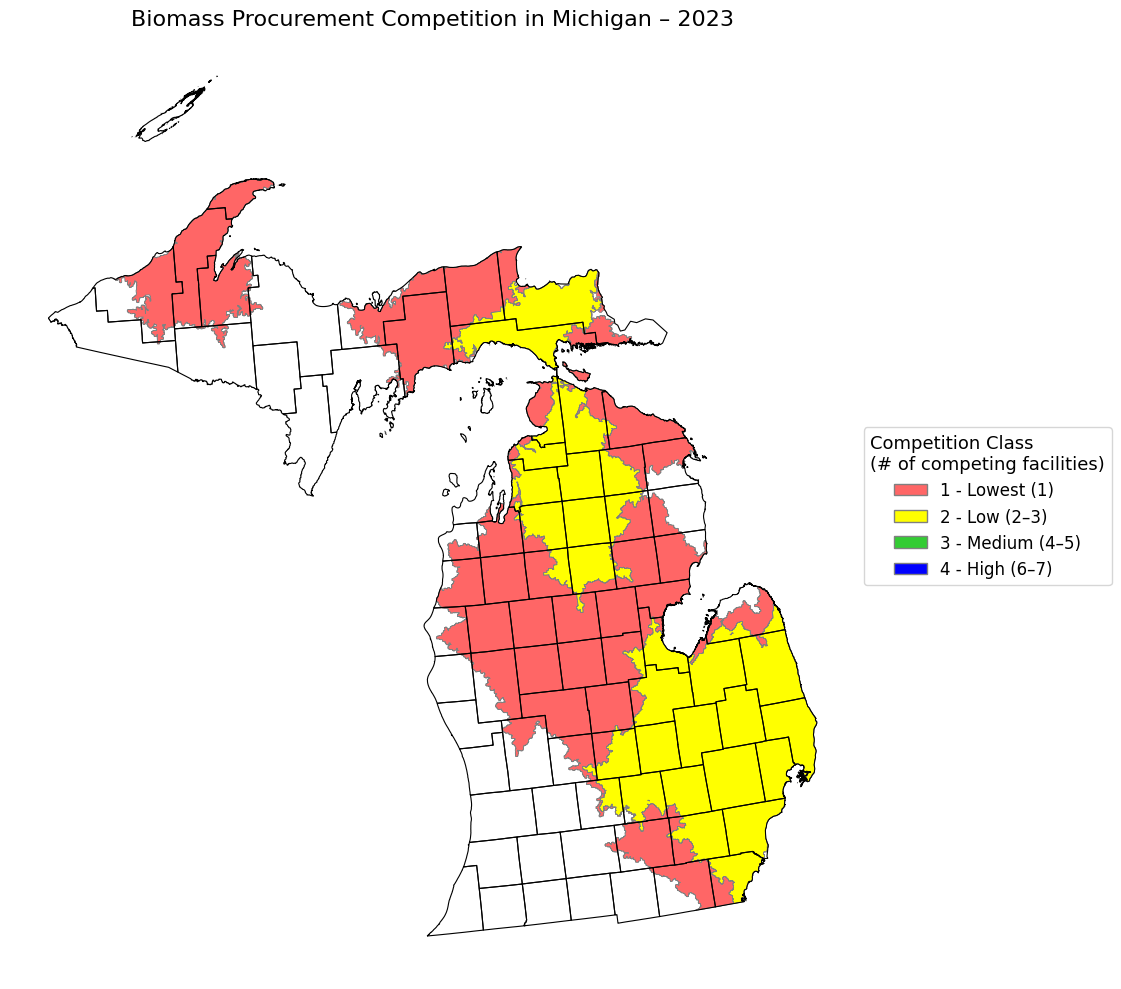

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_biomass_2023 = os.path.join(base_path, "Biomass_2023_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_biomass_2023 = gpd.read_file(hotspot_fp_biomass_2023)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Biomass 2023 hotspots
if gdf_hotspots_biomass_2023.crs != target_crs:
    gdf_hotspots_biomass_2023 = gdf_hotspots_biomass_2023.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_biomass_2023.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2023 Biomass hotspots shapefile!")

# ✅ Color mapping for biomass classes
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_biomass_2023['color'] = gdf_hotspots_biomass_2023['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Biomass 2023 hotspots
gdf_hotspots_biomass_2023.plot(ax=ax, color=gdf_hotspots_biomass_2023['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for biomass classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Biomass Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [36]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Biomass_2023_hotspots.shp"  # 🔄 Updated shapefile path

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 6527059.96 acres
Polygon CompValue 'Low' → Forest area: 3952895.66 acres


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Biomass_2023_hotspots.shp")  # 🔹 Updated to Biomass 2023

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~8200905.30 acres of forest cover.
   - White/Red/Jack Pine Group: 1409734.03 acres
   - Spruce/Fir Group: 1151323.97 acres
   - Exotic Softwoods Group: 123.55 acres
   - Oak/Hickory Group: 10362.97 acres
   - Elm/Ash/Cottonwood Group: 11845.60 acres
   - Maple/Beech/Birch Group: 1511927.39 acres
   - Aspen/Birch Group: 4105587.80 acres

✅ Polygon 'Low' contains ~3869556.19 acres of forest cover.
   - White/Red/Jack Pine Group: 624681.44 acres
   - Spruce/Fir Group: 675075.42 acres
   - Oak/Hickory Group: 7119.71 acres
   - Elm/Ash/Cottonwood Group: 1266.41 acres
   - Maple/Beech/Birch Group: 123.55 acres
   - Aspen/Birch Group: 2561289.66 acres



# Pulpwood

# Pulpwood 1985

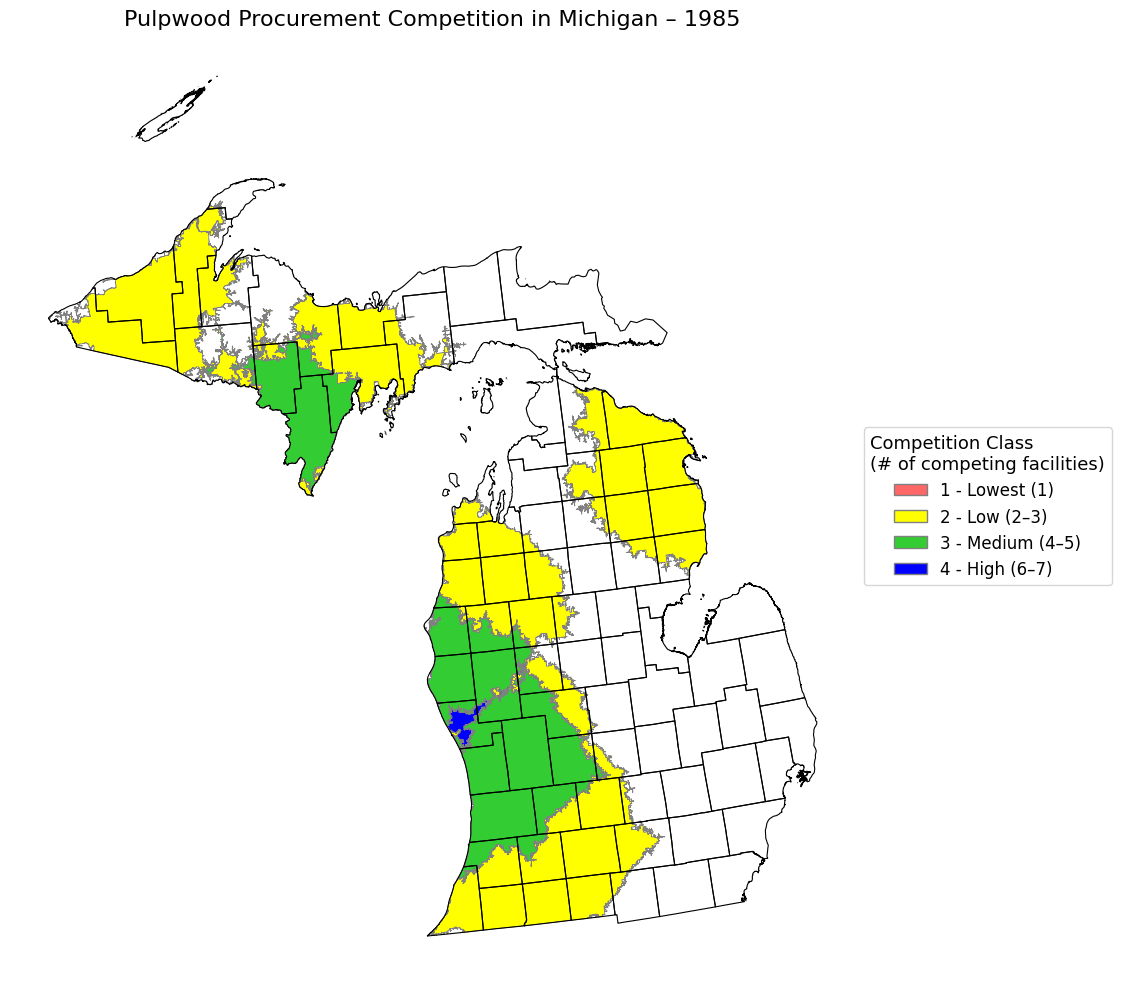

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_pulpwood_1985 = os.path.join(base_path, "Pulpwood_1985_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_pulpwood_1985 = gpd.read_file(hotspot_fp_pulpwood_1985)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Pulpwood 1985 hotspots
if gdf_hotspots_pulpwood_1985.crs != target_crs:
    gdf_hotspots_pulpwood_1985 = gdf_hotspots_pulpwood_1985.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_pulpwood_1985.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1985 Pulpwood hotspots shapefile!")

# ✅ Color mapping for pulpwood classes (same as biomass)
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_pulpwood_1985['color'] = gdf_hotspots_pulpwood_1985['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Pulpwood 1985 hotspots
gdf_hotspots_pulpwood_1985.plot(ax=ax, color=gdf_hotspots_pulpwood_1985['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for pulpwood classes (same as biomass)
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Pulpwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Pulpwood_1985_hotspots.shp"  # 🔹 Updated to Pulpwood 1985 hotspots

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Low' → Forest area: 6518356.55 acres
Polygon CompValue 'Medium' → Forest area: 2145653.46 acres
Polygon CompValue 'High' → Forest area: 62565.36 acres


#using 2019 map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Pulpwood_1985_hotspots.shp")  # 🔹 Updated to Pulpwood 1985

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Low' contains ~8096348.99 acres of forest cover.
   - White/Red/Jack Pine Group: 1078860.43 acres
   - Spruce/Fir Group: 1091354.68 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 109452.07 acres
   - Elm/Ash/Cottonwood Group: 122965.63 acres
   - Maple/Beech/Birch Group: 2472053.86 acres
   - Aspen/Birch Group: 3221507.89 acres

✅ Polygon 'Medium' contains ~2668100.79 acres of forest cover.
   - White/Red/Jack Pine Group: 355676.76 acres
   - Spruce/Fir Group: 510704.26 acres
   - Oak/Hickory Group: 10702.74 acres
   - Elm/Ash/Cottonwood Group: 37853.40 acres
   - Maple/Beech/Birch Group: 425731.03 acres
   - Aspen/Birch Group: 1327432.62 acres

✅ Polygon 'High' contains ~57776.24 acres of forest cover.
   - White/Red/Jack Pine Group: 16154.49 acres
   - Spruce/Fir Group: 61.78 acres
   - Aspen/Birch Group: 41559.97 acres



# Pulpwood 1994


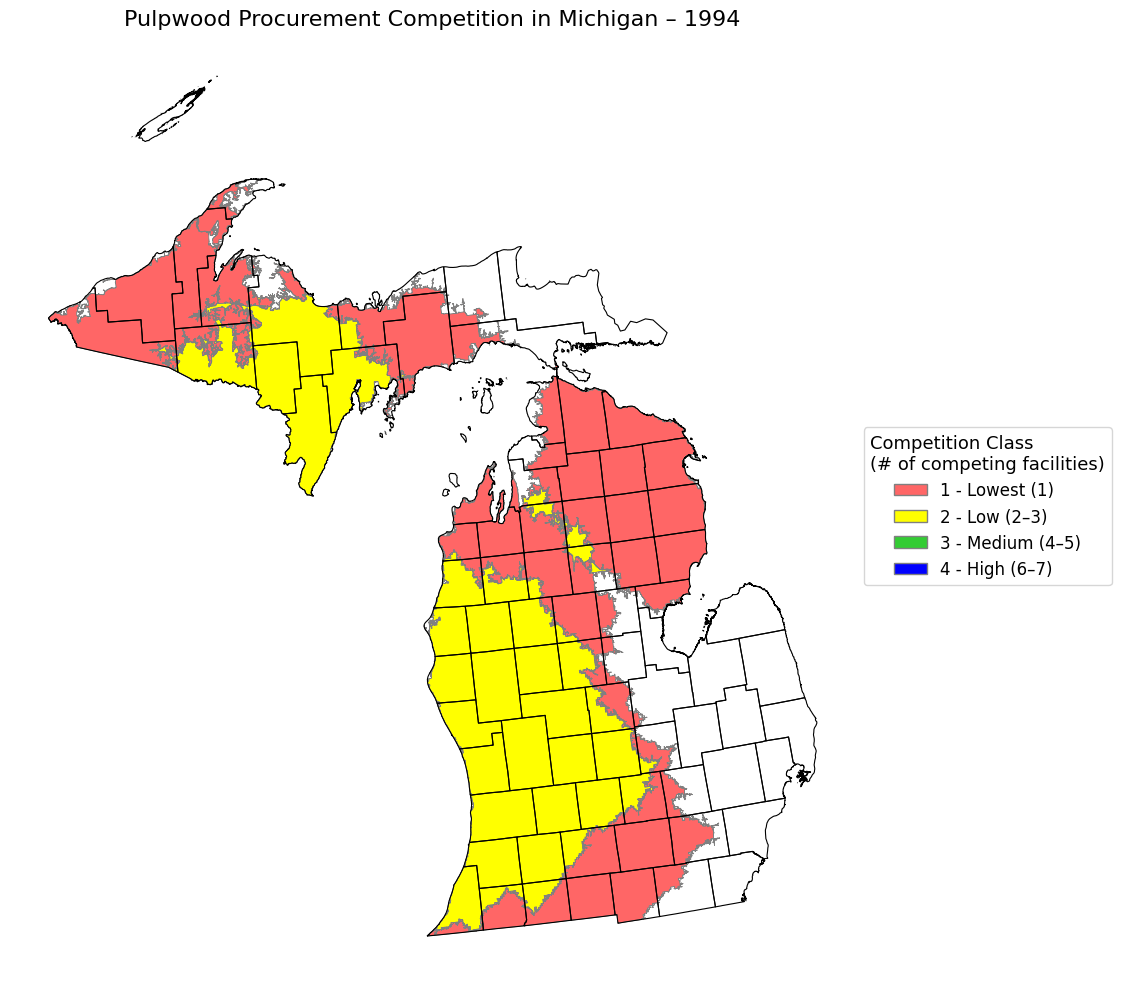

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_pulpwood_1994 = os.path.join(base_path, "Pulpwood_1994_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_pulpwood_1994 = gpd.read_file(hotspot_fp_pulpwood_1994)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Pulpwood 1994 hotspots
if gdf_hotspots_pulpwood_1994.crs != target_crs:
    gdf_hotspots_pulpwood_1994 = gdf_hotspots_pulpwood_1994.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_pulpwood_1994.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 1994 Pulpwood hotspots shapefile!")

# ✅ Color mapping for pulpwood classes (same as biomass)
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_pulpwood_1994['color'] = gdf_hotspots_pulpwood_1994['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Pulpwood 1994 hotspots
gdf_hotspots_pulpwood_1994.plot(ax=ax, color=gdf_hotspots_pulpwood_1994['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for pulpwood classes (same as biomass)
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Pulpwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Pulpwood_1994_hotspots.shp"  # 🔹 Updated to Pulpwood 1994 hotspots

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 7542978.72 acres
Polygon CompValue 'Low' → Forest area: 4752544.00 acres


#using 2019 map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Pulpwood_1994_hotspots.shp")  # 🔹 Updated to Pulpwood 1994

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~9393295.03 acres of forest cover.
   - White/Red/Jack Pine Group: 1299695.08 acres
   - Spruce/Fir Group: 1325610.22 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 76895.99 acres
   - Elm/Ash/Cottonwood Group: 67922.99 acres
   - Maple/Beech/Birch Group: 2439173.46 acres
   - Aspen/Birch Group: 4183858.31 acres

✅ Polygon 'Low' contains ~5727229.81 acres of forest cover.
   - White/Red/Jack Pine Group: 760403.86 acres
   - Spruce/Fir Group: 1031076.50 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 62054.24 acres
   - Elm/Ash/Cottonwood Group: 104386.42 acres
   - Maple/Beech/Birch Group: 1167308.58 acres
   - Aspen/Birch Group: 2601984.76 acres



# Pulpwood 2002

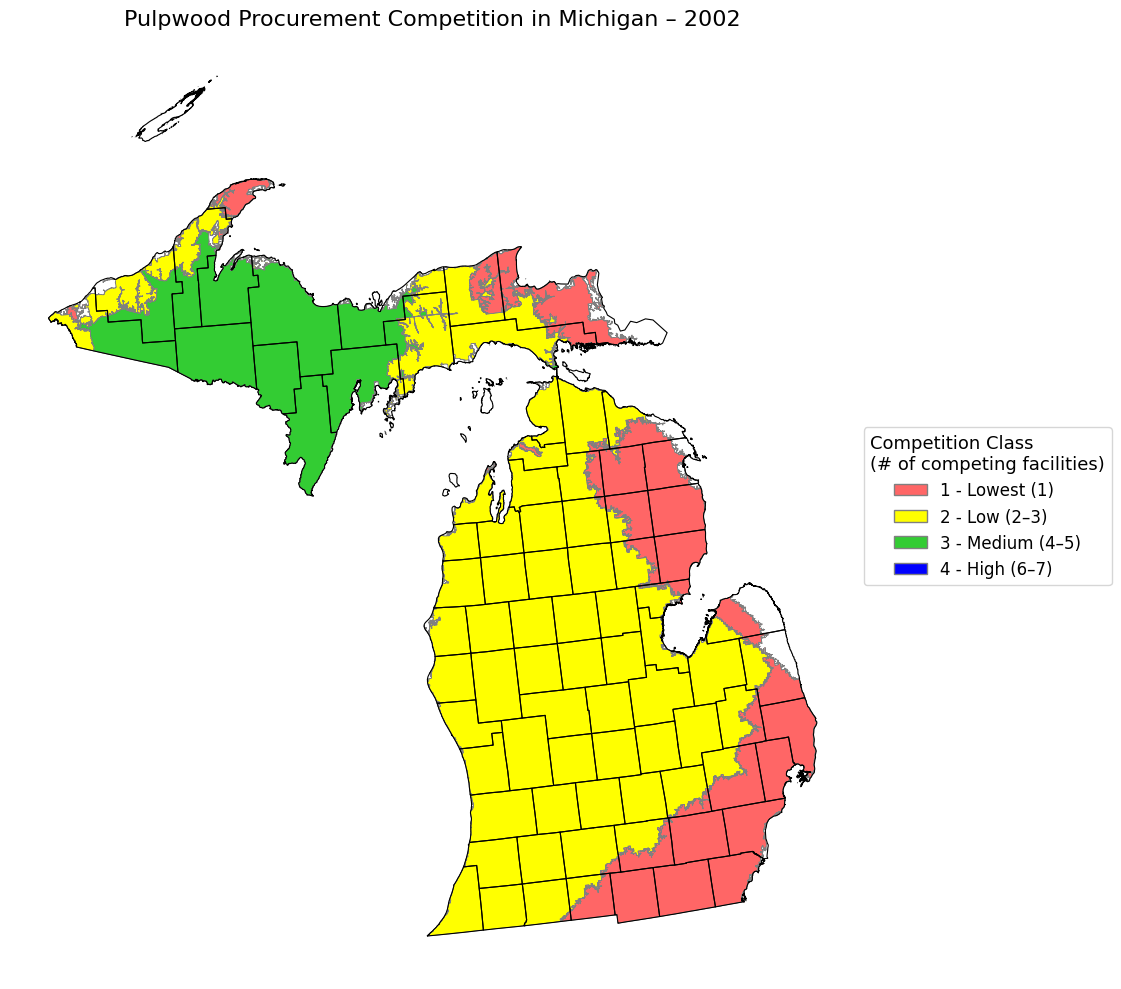

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_pulpwood_2002 = os.path.join(base_path, "Pulpwood_2002_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_pulpwood_2002 = gpd.read_file(hotspot_fp_pulpwood_2002)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Pulpwood 2002 hotspots
if gdf_hotspots_pulpwood_2002.crs != target_crs:
    gdf_hotspots_pulpwood_2002 = gdf_hotspots_pulpwood_2002.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_pulpwood_2002.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2002 Pulpwood hotspots shapefile!")

# ✅ Color mapping for pulpwood classes (same as biomass)
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_pulpwood_2002['color'] = gdf_hotspots_pulpwood_2002['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Pulpwood 2002 hotspots
gdf_hotspots_pulpwood_2002.plot(ax=ax, color=gdf_hotspots_pulpwood_2002['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for pulpwood classes (same as biomass)
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Pulpwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Pulpwood_2002_hotspots.shp"  # 🔹 Updated to Pulpwood 2002 hotspots

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 2838491.50 acres
Polygon CompValue 'Low' → Forest area: 8743136.64 acres
Polygon CompValue 'Medium' → Forest area: 3523184.79 acres


#using 2019 map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Pulpwood_2002_hotspots.shp")  # 🔹 Updated to Pulpwood 2002

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~3192102.39 acres of forest cover.
   - White/Red/Jack Pine Group: 500835.50 acres
   - Spruce/Fir Group: 552248.79 acres
   - Oak/Hickory Group: 32447.98 acres
   - Elm/Ash/Cottonwood Group: 20911.26 acres
   - Maple/Beech/Birch Group: 177158.84 acres
   - Aspen/Birch Group: 1908500.02 acres

✅ Polygon 'Low' contains ~9534407.43 acres of forest cover.
   - White/Red/Jack Pine Group: 1618661.30 acres
   - Spruce/Fir Group: 1061501.30 acres
   - Exotic Softwoods Group: 77.22 acres
   - Oak/Pine Group: 15.44 acres
   - Oak/Hickory Group: 111351.69 acres
   - Elm/Ash/Cottonwood Group: 112602.66 acres
   - Maple/Beech/Birch Group: 831431.10 acres
   - Aspen/Birch Group: 5798766.70 acres

✅ Polygon 'Medium' contains ~5403892.91 acres of forest cover.
   - White/Red/Jack Pine Group: 260634.00 acres
   - Spruce/Fir Group: 1402320.88 acres
   - Exotic Softwoods Group: 61.78 acres
   - Oak/Hickory Group: 9127.44 acres
   - Elm/Ash/Cottonwood Group: 42363.06 acres
   

# Pulpwood 2018

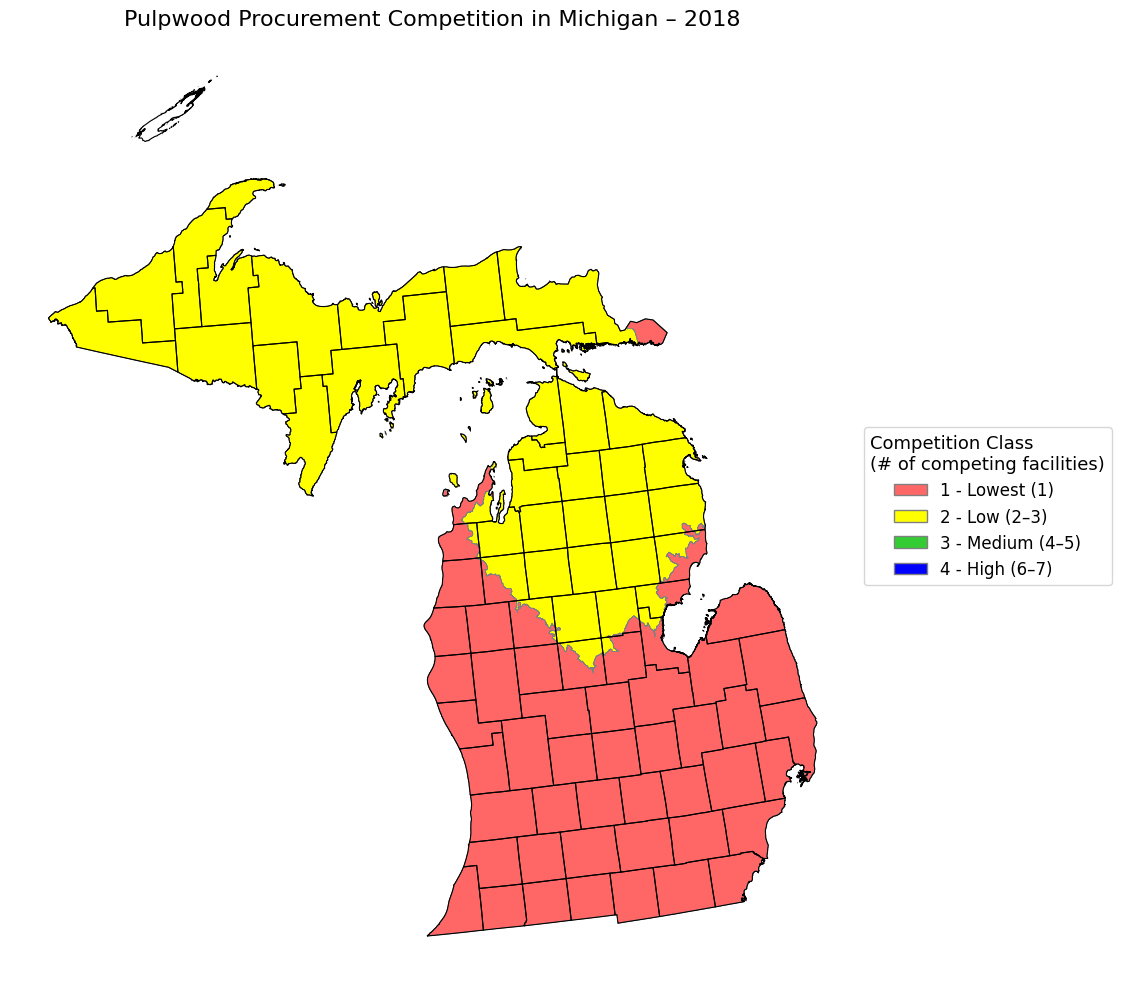

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_pulpwood_2018 = os.path.join(base_path, "Pulpwood_2018_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_pulpwood_2018 = gpd.read_file(hotspot_fp_pulpwood_2018)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Pulpwood 2018 hotspots
if gdf_hotspots_pulpwood_2018.crs != target_crs:
    gdf_hotspots_pulpwood_2018 = gdf_hotspots_pulpwood_2018.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_pulpwood_2018.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2018 Pulpwood hotspots shapefile!")

# ✅ Color mapping for pulpwood classes (same as biomass)
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_pulpwood_2018['color'] = gdf_hotspots_pulpwood_2018['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Pulpwood 2018 hotspots
gdf_hotspots_pulpwood_2018.plot(ax=ax, color=gdf_hotspots_pulpwood_2018['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for pulpwood classes (same as biomass)
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Pulpwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Pulpwood_2018_hotspots.shp"  # 🔹 Updated to Pulpwood 2018 hotspots

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 5399599.91 acres
Polygon CompValue 'Low' → Forest area: 10317940.56 acres


#using 2019 map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Pulpwood_2018_hotspots.shp")  # 🔹 Updated to Pulpwood 2018

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~4468384.27 acres of forest cover.
   - White/Red/Jack Pine Group: 666241.41 acres
   - Spruce/Fir Group: 105297.62 acres
   - Oak/Pine Group: 30.89 acres
   - Oak/Hickory Group: 140046.76 acres
   - Elm/Ash/Cottonwood Group: 126533.20 acres
   - Maple/Beech/Birch Group: 83243.50 acres
   - Aspen/Birch Group: 3346990.89 acres

✅ Polygon 'Low' contains ~14410020.74 acres of forest cover.
   - White/Red/Jack Pine Group: 1769395.35 acres
   - Spruce/Fir Group: 3135870.56 acres
   - Exotic Softwoods Group: 139.00 acres
   - Oak/Hickory Group: 14254.87 acres
   - Elm/Ash/Cottonwood Group: 53266.57 acres
   - Maple/Beech/Birch Group: 3972552.64 acres
   - Aspen/Birch Group: 5464541.75 acres



# Pulpwood 2023

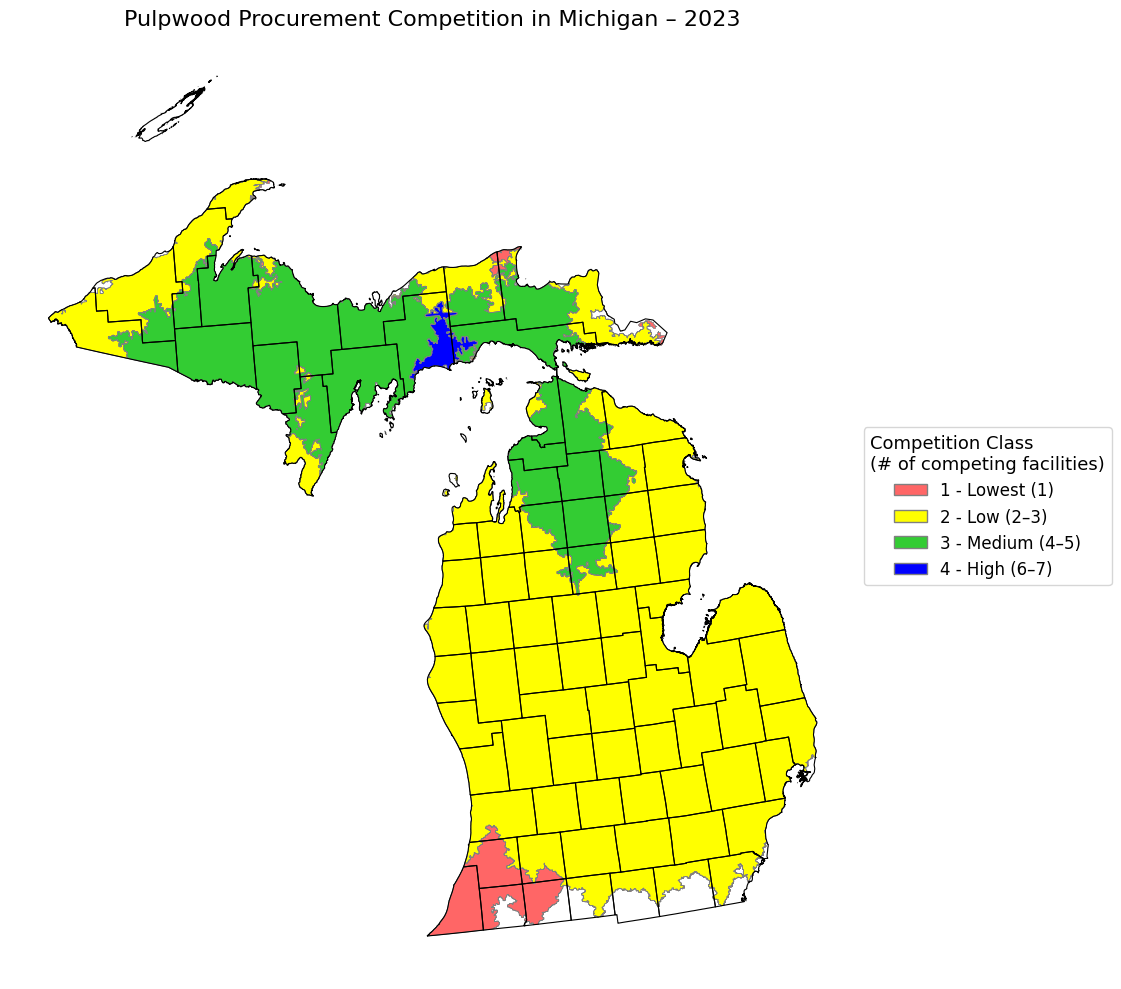

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Set base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
michigan_fp = os.path.join(base_path, "Michigan Counties.shp")
hotspot_fp_pulpwood_2023 = os.path.join(base_path, "Pulpwood_2023_hotspots.shp")

# ✅ Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_pulpwood_2023 = gpd.read_file(hotspot_fp_pulpwood_2023)

# ✅ Target CRS
target_crs = "ESRI:102010"

# ✅ Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# ✅ Reproject Pulpwood 2023 hotspots
if gdf_hotspots_pulpwood_2023.crs != target_crs:
    gdf_hotspots_pulpwood_2023 = gdf_hotspots_pulpwood_2023.to_crs(target_crs)

# ✅ Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots_pulpwood_2023.columns:
    raise ValueError("❌ 'CompValue' column is missing in the 2023 Pulpwood hotspots shapefile!")

# ✅ Color mapping for pulpwood classes (same as biomass)
color_map = {
    'Lowest': '#FF6666',  # red
    'Low': '#FFFF00',     # yellow
    'Medium': '#33CC33',  # green
    'High': '#0000FF'     # blue
}

# ✅ Map colors
gdf_hotspots_pulpwood_2023['color'] = gdf_hotspots_pulpwood_2023['CompValue'].map(color_map)

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Pulpwood 2023 hotspots
gdf_hotspots_pulpwood_2023.plot(ax=ax, color=gdf_hotspots_pulpwood_2023['color'], edgecolor='grey', linewidth=0.5)

# ✅ Custom legend for pulpwood classes (same as biomass)
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis off
ax.set_title("Pulpwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"
raster_path = f"{base_path}/lulc2001.tif"  # Replace with your forest raster
shapefile_path = f"{base_path}/Pulpwood_2023_hotspots.shp"  # 🔹 Updated to Pulpwood 2023 hotspots

# ✅ Forest land cover codes (example)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # Open the shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject shapefile geometries to raster CRS if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Loop over each polygon in the shapefile
        for feature in shp:
            comp_value = feature["properties"].get("CompValue", None)
            geom = feature["geometry"]

            # Reproject geometry if CRS mismatch
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon with CompValue '{comp_value}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            # Mask forest pixels (ignore nodata)
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon CompValue '{comp_value}' → Forest area: {forest_area_acres:.2f} acres")


Polygon CompValue 'Lowest' → Forest area: 295549.61 acres
Polygon CompValue 'Low' → Forest area: 9467233.34 acres
Polygon CompValue 'Medium' → Forest area: 5548153.65 acres
Polygon CompValue 'High' → Forest area: 100951.98 acres


#using 2019 map

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Base path
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Khanal Thesis Data/Data"

# ✅ File paths
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
hotspot_shapefile = os.path.join(base_path, "Pulpwood_2023_hotspots.shp")  # 🔹 Updated to Pulpwood 2023

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(hotspot_shapefile, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for idx, feature in enumerate(shapefile):
            label = feature["properties"].get("CompValue", f"Polygon_{idx}")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"⚠️ Polygon '{label}' does not overlap raster. Skipping...\n")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            if valid_data.size == 0:
                print(f"⚠️ Polygon '{label}' has no valid raster data inside. Skipping...\n")
                continue

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"✅ Polygon '{label}' contains ~{total_area_acres:.2f} acres of forest cover.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   - {forest_type}: {area:.2f} acres")
            print()


✅ Polygon 'Lowest' contains ~286827.13 acres of forest cover.
   - White/Red/Jack Pine Group: 24077.29 acres
   - Spruce/Fir Group: 18409.32 acres
   - Oak/Pine Group: 30.89 acres
   - Oak/Hickory Group: 65034.95 acres
   - Elm/Ash/Cottonwood Group: 51722.17 acres
   - Maple/Beech/Birch Group: 45544.54 acres
   - Aspen/Birch Group: 82007.97 acres

✅ Polygon 'Low' contains ~10016663.72 acres of forest cover.
   - White/Red/Jack Pine Group: 1515556.74 acres
   - Spruce/Fir Group: 866736.23 acres
   - Exotic Softwoods Group: 123.55 acres
   - Oak/Hickory Group: 42409.40 acres
   - Elm/Ash/Cottonwood Group: 73235.74 acres
   - Maple/Beech/Birch Group: 1506892.62 acres
   - Aspen/Birch Group: 6011709.44 acres

✅ Polygon 'Medium' contains ~8148395.48 acres of forest cover.
   - White/Red/Jack Pine Group: 862782.55 acres
   - Spruce/Fir Group: 2228887.10 acres
   - Exotic Softwoods Group: 15.44 acres
   - Oak/Hickory Group: 11814.71 acres
   - Elm/Ash/Cottonwood Group: 36077.33 acres
   - Map